In [2]:
from sentiment import helper, helper2


/Users/sjegoh/Documents/GitHub/NUSSIF/regional_project/venv-regional/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 31662.85it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# In a Jupyter Notebook cell:
try:
    # We call 'await' directly because Notebooks support top-level await
    df_clean, fx_data, bond_data = await helper()
    
    # helper2 is a standard function, so no await needed here
except Exception as e:
    print(f"Error during execution: {e}")


🚀 Accessing BNM...
--- Scraping Page 1 ---
📄 [1] Processing: Deputy Governor's Opening Remarks at the Financing...
📄 [2] Processing: Deputy Governor's Closing Remarks at the SEACEN Po...
📄 [3] Processing: Governor's Opening Remarks at the SEACEN Policy Su...
📄 [4] Processing: Deputy Governor's Keynote Speech at the Launch of ...
📄 [5] Processing: Assistant Governor's Speech at the PPKM Annual Din...
📄 [6] Processing: Ucapan Gabenor di Peringkat Akhir Pertandingan Pid...
📄 [7] Processing: Governor's Keynote Address at the Malaysian e-Paym...
📄 [8] Processing: Assistant Governor's Keynote Presentation at the K...
📄 [9] Processing: Assistant Governor's Keynote Address at the JC3 SM...
📄 [10] Processing: Governor's Keynote Address at the 48th Federation ...
📄 [11] Processing: Deputy Governor's Speech at the Closing of Karniva...
📄 [12] Processing: Governor's Welcoming Speech at the Launch of Karni...
📄 [13] Processing: Governor's Opening Remarks at the 15th Internation...
📄 [14] Processing

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
import torch
import pandas as pd
import re
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from deep_translator import GoogleTranslator
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.dates as mdates
from scipy import stats
import numpy as np


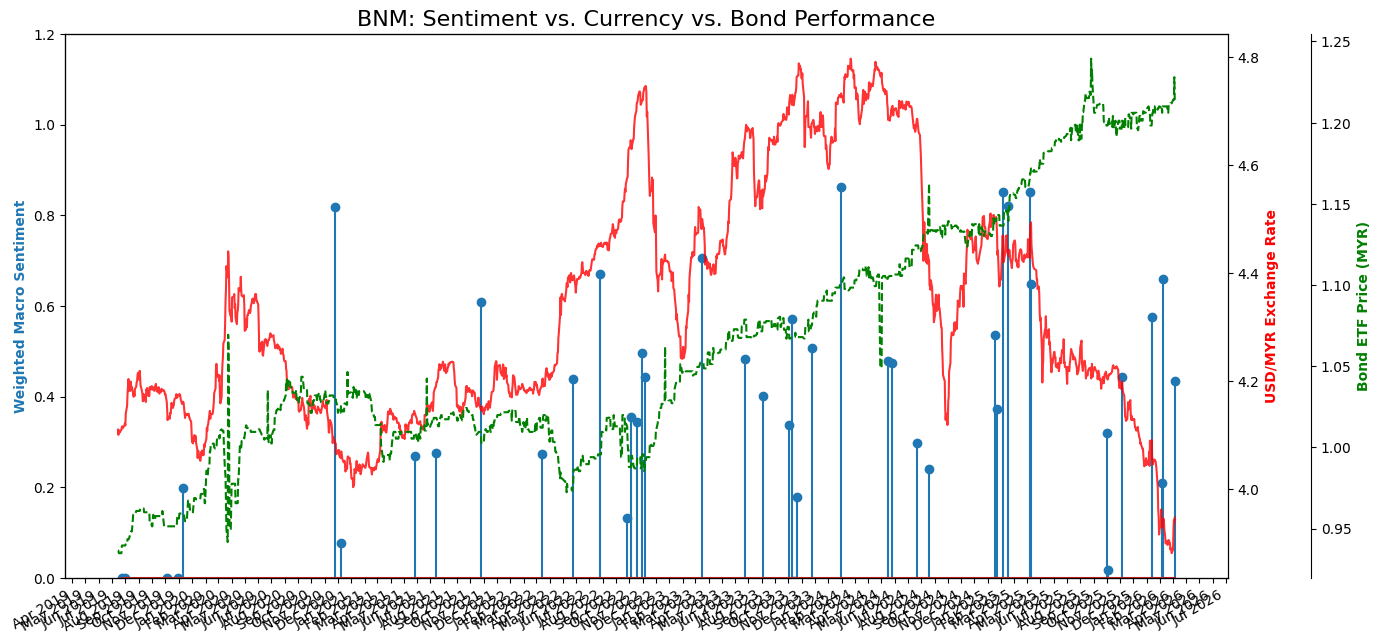


--- Multi-Horizon Robust Analysis ---
    Horizon     Asset    Corr  p-value
0    3 Days   USD/MYR -0.3509   0.0195
1   30 Days   USD/MYR -0.2424   0.1128
2  100 Days   USD/MYR -0.1498   0.3316
0    3 Days  Bond ETF  0.3171   0.0360
1   30 Days  Bond ETF  0.1245   0.4206
2  100 Days  Bond ETF  0.0587   0.7049


In [5]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
fx_data['Date'] = pd.to_datetime(fx_data['Date']).dt.tz_localize(None)
bond_data['Date'] = pd.to_datetime(bond_data['Date']).dt.tz_localize(None)

# Plotting code remains the same as your request
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.stem(df_clean['Date'], df_clean['Sentiment'], linefmt='C0-', markerfmt='C0o', label='BNM Sentiment')
ax1.set_ylabel('Weighted Macro Sentiment', color='C0', fontweight='bold')
ax1.set_ylim(0, 1.2)

ax2 = ax1.twinx()
ax2.plot(fx_data['Date'].values, fx_data['Close'].values, color='red', linewidth=1.5, label='USD/MYR Spot', alpha=0.8)
ax2.set_ylabel('USD/MYR Exchange Rate', color='red', fontweight='bold')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(bond_data['Date'].values, bond_data['Close'].values, color='green', linewidth=1.5, label='ABF Bond ETF (0800EA.KL)', linestyle='--')
ax3.set_ylabel('Bond ETF Price (MYR)', color='green', fontweight='bold')

ax1.xaxis_date() 
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate()
plt.title('BNM: Sentiment vs. Currency vs. Bond Performance', fontsize=16)
plt.show()

# Robust Horizon Evaluation
def evaluate_horizons_robust(df_sent, mkt_data, horizons=[3, 30, 100], label="FX"):
    # 1. Normalize resolution to nanoseconds (ns) and strip timezones
    # We call .astype() on the Series, NOT the .dt accessor
    df_sent['Date'] = pd.to_datetime(df_sent['Date']).astype('datetime64[ns]')
    
    # For market data, we strip the timezone first, THEN cast
    mkt_data['Date'] = pd.to_datetime(mkt_data['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    
    # 2. Sort is MANDATORY for merge_asof
    df_sent = df_sent.sort_values('Date')
    mkt_data = mkt_data.sort_values('Date')
    
    results = []
    # ... rest of your loop logic
    # ... rest of your loop logic
    for h in horizons:
        mkt_temp = mkt_data.copy()
        mkt_temp['Target_Date'] = mkt_temp['Date'] + pd.Timedelta(days=h)
        mkt_future = pd.merge_asof(mkt_temp[['Target_Date']], mkt_data[['Date', 'Close']], left_on='Target_Date', right_on='Date', direction='backward').rename(columns={'Close': 'Future_Price'})
        mkt_temp['Forward_Return'] = (mkt_future['Future_Price'] - mkt_temp['Close']) / mkt_temp['Close']
        merged = pd.merge_asof(df_sent, mkt_temp[['Date', 'Forward_Return']], on='Date', direction='backward')
        valid = merged.dropna(subset=['Forward_Return'])
        if len(valid) > 2:
            r, p = stats.pearsonr(valid['Sentiment'], valid['Forward_Return'])
            results.append({'Horizon': f'{h} Days', 'Asset': label, 'Corr': round(r, 4), 'p-value': round(p, 4)})
    return pd.DataFrame(results)

print("\n--- Multi-Horizon Robust Analysis ---")
fx_results = evaluate_horizons_robust(df_clean, fx_data, label="USD/MYR")
bond_results = evaluate_horizons_robust(df_clean, bond_data, label="Bond ETF")
print(pd.concat([fx_results, bond_results]))




In [6]:
def evaluate_horizons_robust_diffs(df_sent, mkt_data, horizons=[3, 30, 100], label="FX"):
    # 1. Pre-process dates and sort (Crucial for merge_asof and diff calculations)
    df_sent = df_sent.copy()
    mkt_data = mkt_data.copy()
    
    df_sent['Date'] = pd.to_datetime(df_sent['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    mkt_data['Date'] = pd.to_datetime(mkt_data['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    
    df_sent = df_sent.sort_values('Date')
    mkt_data = mkt_data.sort_values('Date')

    # 2. CALCULATE DIFFERENCES (The Change in Sentiment)
    # This captures the 'Surprise' factor (Sentiment at t minus Sentiment at t-1)
    df_sent['Sentiment_Diff'] = df_sent['Sentiment'].diff()

    results = []

    for h in horizons:
        mkt_temp = mkt_data.copy()
        
        # 3. CALCULATE FORWARD LOG RETURNS (Standard for price differences)
        # Using Log Returns ensures the differences are additive and normalized
        mkt_temp['Log_Price'] = np.log(mkt_temp['Close'])
        
        # Shift prices back by 'h' periods to get the future price
        # Note: In a daily index, 'h' periods approx 'h' days. 
        # For precise calendar days, use the Target_Date merge logic below:
        
        mkt_temp['Target_Date'] = mkt_temp['Date'] + pd.Timedelta(days=h)
        
        mkt_future = pd.merge_asof(
            mkt_temp[['Target_Date']], 
            mkt_temp[['Date', 'Log_Price']], 
            left_on='Target_Date', 
            right_on='Date', 
            direction='backward'
        ).rename(columns={'Log_Price': 'Future_Log_Price'})
        
        # Difference in Log Prices = Log Return
        mkt_temp['Forward_Diff_Return'] = mkt_future['Future_Log_Price'].values - mkt_temp['Log_Price'].values
        
        # 4. Merge Sentiment Change with Forward Price Change
        merged = pd.merge_asof(df_sent, mkt_temp[['Date', 'Forward_Diff_Return']], on='Date', direction='backward')
        
        # Drop the first row of Sentiment_Diff (it's NaN) and any missing returns
        valid = merged.dropna(subset=['Sentiment_Diff', 'Forward_Diff_Return'])
        
        if len(valid) > 2:
            # Correlation between CHANGE in sentiment and CHANGE in future price
            r, p = stats.pearsonr(valid['Sentiment_Diff'], valid['Forward_Diff_Return'])
            results.append({
                'Horizon': f'{h} Days', 
                'Asset': label, 
                'Corr (Δ)': round(r, 4), 
                'p-value': round(p, 4),
                'N': len(valid)
            })
            
    return pd.DataFrame(results)

print("\n--- Multi-Horizon Difference-Based Analysis ---")
fx_diff_results = evaluate_horizons_robust_diffs(df_clean, fx_data, label="USD/MYR")
bond_diff_results = evaluate_horizons_robust_diffs(df_clean, bond_data, label="Bond ETF")
print(pd.concat([fx_diff_results, bond_diff_results]))



--- Multi-Horizon Difference-Based Analysis ---
    Horizon     Asset  Corr (Δ)  p-value   N
0    3 Days   USD/MYR   -0.2183   0.1595  43
1   30 Days   USD/MYR   -0.0417   0.7906  43
2  100 Days   USD/MYR    0.0575   0.7141  43
0    3 Days  Bond ETF    0.2208   0.1547  43
1   30 Days  Bond ETF    0.2843   0.0647  43
2  100 Days  Bond ETF    0.1701   0.2754  43


In [7]:
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.preprocessing import StandardScaler

def run_granger_test_standardized(df_clean, mkt_data, max_lag=15):
    # 1. Calculate Sentiment CHANGE on the specific speech dates ONLY
    df_clean = df_clean.sort_values('Date').copy()
    df_clean['Sent_Diff'] = df_clean['Sentiment']
    
    # 2. Prepare Market Data
    mkt_data = mkt_data.sort_values('Date').copy()
    mkt_data['Mkt_Ret'] = mkt_data['Close'].pct_change()
    
    # 3. Merge Sentiment DIFF onto the daily Market Timeline
    test_df = pd.merge(mkt_data[['Date', 'Mkt_Ret']], 
                       df_clean[['Date', 'Sent_Diff']], 
                       on='Date', how='left').fillna(0)
    
    # 4. THE STANDARDIZATION STEP
    # We transform both variables into Z-Scores
    scaler = StandardScaler()
    test_df[['Mkt_Ret_Z', 'Sent_Diff_Z']] = scaler.fit_transform(test_df[['Mkt_Ret', 'Sent_Diff']])
    
    # Drop first row (NaN)
    final_data = test_df[['Mkt_Ret_Z', 'Sent_Diff_Z']].dropna()
    
    print(f"\n--- Standardized Granger Causality Test (Z-Scores) ---")
    # [Dependent (Y), Independent (X)]
    results = grangercausalitytests(final_data[['Mkt_Ret_Z', 'Sent_Diff_Z']], maxlag=max_lag, verbose=True)
    
    return results

# Run the standardized test for Bond Data
standard_granger = run_granger_test_standardized(df_clean, fx_data)



--- Standardized Granger Causality Test (Z-Scores) ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.8734  , p=0.0902  , df_denom=1725, df_num=1
ssr based chi2 test:   chi2=2.8784  , p=0.0898  , df=1
likelihood ratio test: chi2=2.8760  , p=0.0899  , df=1
parameter F test:         F=2.8734  , p=0.0902  , df_denom=1725, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.9182  , p=0.0543  , df_denom=1722, df_num=2
ssr based chi2 test:   chi2=5.8534  , p=0.0536  , df=2
likelihood ratio test: chi2=5.8435  , p=0.0538  , df=2
parameter F test:         F=2.9182  , p=0.0543  , df_denom=1722, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.4207  , p=0.0042  , df_denom=1719, df_num=3
ssr based chi2 test:   chi2=13.3162 , p=0.0040  , df=3
likelihood ratio test: chi2=13.2650 , p=0.0041  , df=3
parameter F test:         F=4.4207  , p=0.0042  , df_denom=1719, df_num=3

Granger Causality
number of lag

/Users/sjegoh/Documents/GitHub/NUSSIF/regional_project/venv-regional/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rolling_regime_analysis(df_sent, df_bond, window=252):
    # 1. Sync and Calculate (MA30 and Forward 30D Ret)
    df_sent = df_sent.sort_values('Date').copy()
    df_bond = df_bond.sort_values('Date').copy()
    
    df_sent['Sent_MA30'] = df_sent['Sentiment'].rolling(window=30).mean()
    df_bond['Forward_30D_Ret'] = df_bond['Close'].pct_change(30).shift(-30)
    
    # 2. Merge on Date
    combined = pd.merge(df_bond[['Date', 'Forward_30D_Ret']], 
                        df_sent[['Date', 'Sent_MA30']], 
                        on='Date', how='inner').dropna()
    
    # 3. Calculate Rolling Correlation (1-Year Window)
    combined['Rolling_Corr'] = combined['Forward_30D_Ret'].rolling(window=window).corr(combined['Sent_MA30'])
    
    # 4. Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(combined['Date'], combined['Rolling_Corr'], color='#2c3e50', linewidth=2, label='1-Year Rolling Correlation')
    
    # Add a horizontal line for your -0.61 average
    plt.axhline(y=-0.61, color='red', linestyle='--', alpha=0.6, label='Overall Average (-0.61)')
    plt.axhline(y=0, color='black', alpha=0.2)
    
    plt.fill_between(combined['Date'], combined['Rolling_Corr'], -0.61, where=(combined['Rolling_Corr'] < -0.61), color='green', alpha=0.1, label='Stronger than Avg')
    plt.fill_between(combined['Date'], combined['Rolling_Corr'], -0.61, where=(combined['Rolling_Corr'] > -0.61), color='orange', alpha=0.1, label='Weaker than Avg')

    plt.title('Time-Varying Regime Correlation: BNM Sentiment vs. Bond Returns', fontsize=14)
    plt.ylabel('Correlation Coefficient (r)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. Annual Breakdown for your report
    combined['Year'] = combined['Date'].dt.year
    annual_corr = combined.groupby('Year').apply(lambda x: x['Forward_30D_Ret'].corr(x['Sent_MA30']))
    print("\n--- Annual Regime Correlation ---")
    print(annual_corr)
    print(f"Sentiment Data starts: {df_clean['Date'].min()}")
    print(f"Bond Data starts:      {bond_data['Date'].min()}")
    print(f"Merged Data starts:    {combined['Date'].min()}")

# Run the analysis
def recover_history_analysis(df_sent, df_bond):
    # 1. Start with the Bond Data (continuous timeline)
    full_df = df_bond[['Date', 'Close']].sort_values('Date').copy()
    full_df['Forward_30D_Ret'] = full_df['Close'].pct_change(30).shift(-30)
    
    # 2. Left Join Sentiment (Keep all Bond dates)
    combined = pd.merge(full_df, df_sent[['Date', 'Sentiment']], on='Date', how='left')
    
    # 3. CRITICAL STEP: Forward Fill the policy stance
    # This assumes BNM's stance stays the same until the next speech
    combined['Sentiment'] = combined['Sentiment'].ffill()
    
    # 4. Now calculate the MA on the filled data
    combined['Sent_MA30'] = combined['Sentiment'].rolling(window=30).mean()
    
    # 5. Drop only the very beginning/end where windows can't be full
    final = combined.dropna(subset=['Sent_MA30', 'Forward_30D_Ret'])
    
    print(f"NEW Merged Data starts: {final['Date'].min()}")
    return final

# Run this and re-check annual correlations
df_recovered = recover_history_analysis(df_clean, fx_data)
annual_corr_recovered = df_recovered.groupby(df_recovered['Date'].dt.year).apply(
    lambda x: x['Forward_30D_Ret'].corr(x['Sent_MA30'])
)
print(annual_corr_recovered)


NEW Merged Data starts: 2019-09-03 00:00:00
Date
2019    0.107990
2020   -0.071154
2021   -0.354570
2022    0.382497
2023    0.280692
2024   -0.134988
2025    0.024256
2026    0.774139
dtype: float64


In [9]:
def check_trigger_efficiency(df_recovered):
    # 1. Calculate Z-Scores for Sentiment
    # This tells us how 'Extreme' a speech is relative to the 7-year history
    mu = df_recovered['Sent_MA30'].mean()
    sigma = df_recovered['Sent_MA30'].std()
    df_recovered['Sent_Z'] = (df_recovered['Sent_MA30'] - mu) / sigma

    # 2. Define our "Trigger" thresholds (Standard Deviations)
    thresholds = [0.5, 1.0, 1.5, 2.0]
    
    print(f"{'Threshold (Z)':<15} | {'N Days':<8} | {'Correlation (r)':<15}")
    print("-" * 45)
    
    for t in thresholds:
        # Filter for days where sentiment is more extreme than 't'
        subset = df_recovered[df_recovered['Sent_Z'].abs() > t]
        
        if len(subset) > 1:
            corr = subset['Sent_MA30'].corr(subset['Forward_30D_Ret'])
            print(f"|Z| > {t:<10.1f} | {len(subset):<8} | {corr:<15.4f}")
        else:
            print(f"|Z| > {t:<10.1f} | {len(subset):<8} | Insufficient Data")

# Run the Trigger Test
check_trigger_efficiency(df_recovered)


Threshold (Z)   | N Days   | Correlation (r)
---------------------------------------------
|Z| > 0.5        | 1221     | -0.0042        
|Z| > 1.0        | 549      | -0.0474        
|Z| > 1.5        | 187      | -0.1058        
|Z| > 2.0        | 51       | -0.2534        


In [10]:
import numpy as np
import pandas as pd

class RegimeTactician:
    def __init__(self, lookback_days=60):
        self.lookback = lookback_days
        self.threshold = 1.5  # Your "Golden Z-Score"
        
    def get_market_state(self, df_combined):
        """
        Analyzes the last 60 days to see if the 'Signal' is currently working.
        Returns: 'Active', 'Flipped', or 'Noise'
        """
        recent_data = df_combined.tail(self.lookback)
        recent_corr = recent_data['Sent_MA30'].corr(recent_data['Forward_30D_Ret'])
        
        if recent_corr < -0.4:
            return "Active (Hawkish = MYR Strength)"
        elif recent_corr > 0.4:
            return "Flipped (Hawkish = MYR Weakness)"
        else:
            return "Noise (No Alpha)"

    def sniper_trigger(self, current_sentiment_z, state):
        """
        The final Execution Gate.
        """
        # Logic: Only trade if we have Conviction AND a clear Regime
        if abs(current_sentiment_z) < self.threshold:
            return "HOLD: Low Conviction (|Z| < 1.5)"
        
        if "Noise" in state:
            return "HOLD: Regime is currently Noise"
            
        if "Active" in state:
            if current_sentiment_z > self.threshold:
                return "EXECUTE: LONG MYR (Strong Signal)"
            else:
                return "EXECUTE: SHORT MYR (Strong Signal)"
                
        if "Flipped" in state:
            # In 2026, Hawkish (+Z) might mean a weaker Ringgit
            if current_sentiment_z > self.threshold:
                return "EXECUTE: SHORT MYR (Contrarian/Flipped Signal)"
            
        return "WAIT"

# Usage in your main AI loop:
tactician = RegimeTactician()
current_state = tactician.get_market_state(df_recovered)
print(current_state)


Active (Hawkish = MYR Strength)


Changes in sentiment generally reflected in 3 days in exchange rate. Seems tradable...?

[*********************100%***********************]  1 of 1 completed


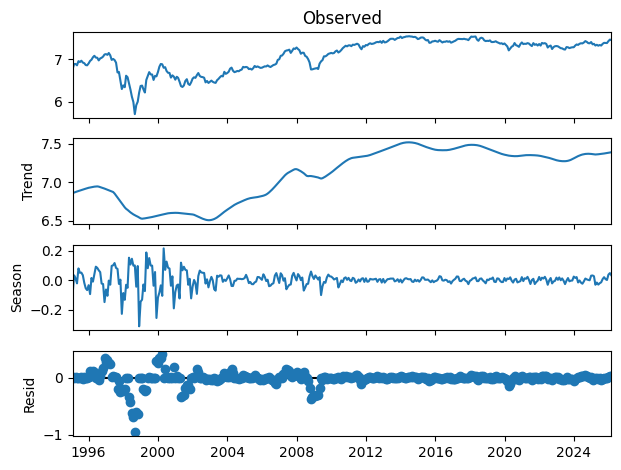

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. Get Data
ticker = "^KLSE"
data = yf.download(ticker, start="1995-01-01", end="2026-03-01")
prices = data['Close'].resample('ME').last().ffill() # Monthly resample

# 2. Log transform to handle exponential growth/percentage changes
log_prices = np.log(prices)

# 3. Apply STL
# period=12 because we are looking for annual (monthly) seasonality
stl = STL(log_prices, period=12, robust=True)
res = stl.fit()

# 4. Plot the components
fig = res.plot()
plt.show()


In [12]:
# Extract the seasonal component
seasonal_component = res.seasonal

# Group by month to see the average 'strength' of the season
monthly_seasonality = seasonal_component.groupby(seasonal_component.index.month).mean()

# Convert back from log scale to see approximate % impact
impact_pct = (np.exp(monthly_seasonality) - 1) * 100
# 1. Calculate Monthly Returns from your original 'prices' series
monthly_returns = prices.pct_change()

# 2. Define a 'Win' (True if return > 0)
is_win = monthly_returns > 0

# 3. Group by month to get the Win Rate (%)
# we multiply by 100 to get a percentage
win_rate = is_win.groupby(is_win.index.month).mean() * 100

# 4. Combine with your existing 'impact_pct' (Seasonality Strength)
# 1. Flatten the seasonal strength and win rate to ensure they are 1D
# .squeeze() turns a (12, 1) into a (12,)
strength_1d = impact_pct.squeeze()
win_rate_1d = win_rate.squeeze()

# 2. Combine into DataFrame
seasonality_analysis = pd.DataFrame({
    'Seasonal Strength (%)': strength_1d,
    'Win Rate (%)': win_rate_1d
})

# 3. Format
seasonality_analysis.index.name = 'Month'
print(seasonality_analysis.round(2))


       Seasonal Strength (%)  Win Rate (%)
Month                                     
1                      -1.25         53.12
2                       0.48         62.50
3                      -1.63         45.16
4                       3.03         58.06
5                       0.77         45.16
6                       1.35         51.61
7                       1.77         51.61
8                       1.64         41.94
9                      -0.70         38.71
10                      0.94         67.74
11                     -4.60         38.71
12                     -1.20         90.32


--- KELLY-SIZED SEASONAL RISK REPORT ---
Total Return:      111.88%
Annualized Sharpe: 0.5449
Max Drawdown:      -16.30%
--- SIZING ANALYSIS ---
Max Position Size: 82.3%
Min Position Size: 3.7% (Active Trades Only)


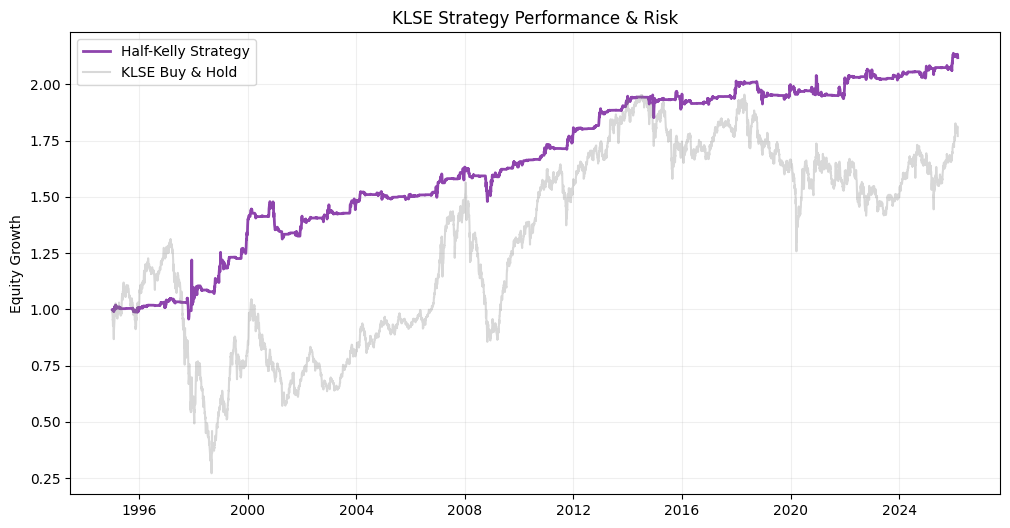

In [13]:
def run_seasonal_backtest_kelly(data, seasonality_analysis):
    df = data.copy()
    
    # 1. Prepare seasonality and monthly stats for Win/Loss Ratio (R)
    seasonality_analysis.index = seasonality_analysis.index.astype(int)
    df['Month'] = df.index.month
    df['Market_Ret'] = df['Close'].pct_change()
    
    # Calculate historical Win/Loss Ratio per month to get 'R'
    monthly_stats = {}
    for m in range(1, 13):
        m_rets = df[df['Month'] == m]['Market_Ret'].dropna()
        pos_rets = m_rets[m_rets > 0].mean()
        neg_rets = abs(m_rets[m_rets < 0].mean())
        monthly_stats[m] = pos_rets / neg_rets if neg_rets != 0 else 1.0

    # 2. Map Kelly Components
    df['W'] = df['Month'].map(seasonality_analysis['Win Rate (%)']) / 100.0
    df['R'] = df['Month'].map(monthly_stats)
    
    # Kelly Formula: K = W - ((1-W)/R)
    df['Kelly_Fraction'] = df['W'] - ((1 - df['W']) / df['R'])
    df['Sizing_Factor'] = df['Kelly_Fraction'] * 1.0 # Half-Kelly
    
    # 3. Execution Logic
    kelly_arr = df['Sizing_Factor'].values.flatten()
    win_rate_arr = df['W'].values.flatten()

    # Rule: Only trade if Kelly is positive (>0) and Win Rate > 50%
    df['Position_Size'] = np.where(
        (kelly_arr > 0) & (win_rate_arr > 0.5),
        kelly_arr.clip(0, 1.0), 
        0
    )

    # 4. Calculate Strategy Returns
    df['Strategy_Ret'] = df['Position_Size'].shift(1) * df['Market_Ret']
    
    # 5. Metrics & Performance
    clean_rets = df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        # --- NEW METRICS CALCULATIONS ---
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        vol = clean_rets.std() * np.sqrt(252)
        sharpe = (clean_rets.mean() * 252) / vol if vol != 0 else 0
        
        # Max Drawdown: Peak to Trough
        rolling_max = cumulative_ret.cummax()
        drawdowns = (cumulative_ret - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        
        # Sizing Extremes (Active trades only for Min)
        max_size = df['Position_Size'].max()
        active_sizes = df[df['Position_Size'] > 0]['Position_Size']
        min_size = active_sizes.min() if not active_sizes.empty else 0

        print(f"--- KELLY-SIZED SEASONAL RISK REPORT ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"--- SIZING ANALYSIS ---")
        print(f"Max Position Size: {max_size*100:.1f}%")
        print(f"Min Position Size: {min_size*100:.1f}% (Active Trades Only)")
        
        # Plotting remains the same
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label="Half-Kelly Strategy", color='#8e44ad', linewidth=2)
        plt.plot((1 + df['Market_Ret'].dropna()).cumprod(), label="KLSE Buy & Hold", alpha=0.3, color='gray')
        plt.title("KLSE Strategy Performance & Risk")
        plt.ylabel("Equity Growth")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    else:
        print("Error: No trade data generated.")

# Run it
run_seasonal_backtest_kelly(data, seasonality_analysis)


EWMA Strategy (Span=10Y): 2005 - 2026
--- EWMA CONVICTION (SPAN 10Y) ---
Total Return:      105.35%
Annualized Sharpe: 0.6792
Max Drawdown:      -26.07%


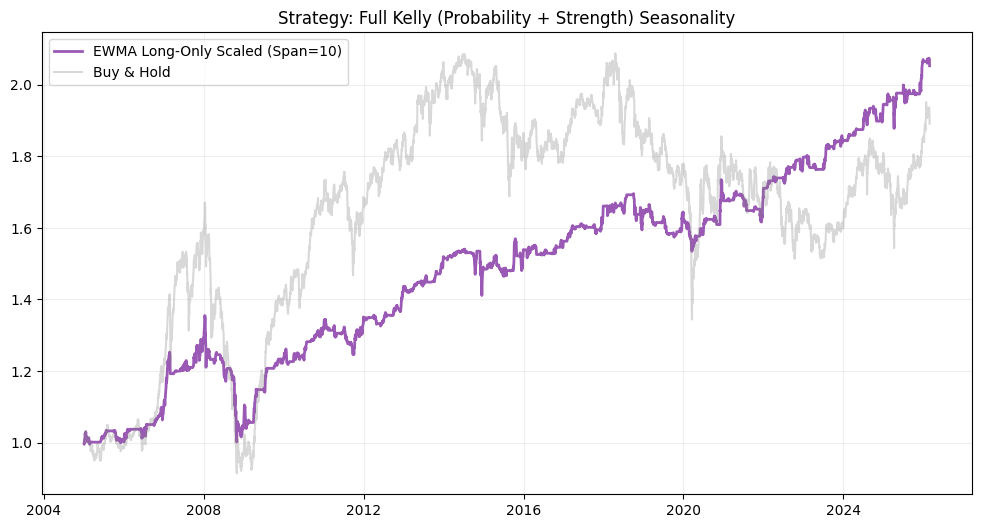

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_ewma_conviction_long_only(data, span=30, scale_conviction=True):
    df = data.copy()
    
    # Handle MultiIndex columns if they exist
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df['Market_Ret'] = df['Close'].pct_change()
    df['Month'] = df.index.month
    df['Strategy_Ret'] = 0.0
    
    DATA_START_YEAR = df.index.year.min()
    TRADING_START_YEAR = DATA_START_YEAR + span
    END_YEAR = df.index.year.max()
    
    print(f"EWMA Strategy (Span={span}Y): {TRADING_START_YEAR} - {END_YEAR}")

    for year in range(TRADING_START_YEAR, END_YEAR + 1):
        # 1. TRAIN: All data before the current year
        train_data = df[df.index.year < year].copy()
        
        # 2. Calculate EWMA for Probability AND Strength
        train_data['is_win'] = (train_data['Market_Ret'] > 0).astype(int)
        
        # Separate the actual return magnitudes
        train_data['win_ret'] = np.where(train_data['Market_Ret'] > 0, train_data['Market_Ret'], np.nan)
        train_data['loss_ret'] = np.where(train_data['Market_Ret'] < 0, np.abs(train_data['Market_Ret']), np.nan)
        
        # Group by year and month to get the averages for each specific month
        yearly_stats = train_data.groupby([train_data.index.year, 'Month']).agg(
            win_rate=('is_win', 'mean'),
            avg_win=('win_ret', 'mean'),
            avg_loss=('loss_ret', 'mean')
        ).unstack('Month')
        
        # Apply EWMA to all three metrics
        ewma_win_rate = yearly_stats['win_rate'].ewm(span=span).mean().iloc[-1]
        ewma_avg_win = yearly_stats['avg_win'].ewm(span=span).mean().iloc[-1]
        ewma_avg_loss = yearly_stats['avg_loss'].ewm(span=span).mean().iloc[-1]

        # 3. TEST: Apply to the current year
        current_year_mask = df.index.year == year
        
        # --- PRE-CALCULATE RELATIVE CONVICTION (FULL KELLY) ---
        raw_sizes = {}
        for month in range(1, 13):
            p = ewma_win_rate[month]
            avg_w = ewma_avg_win[month]
            avg_l = ewma_avg_loss[month]
            
            # Handle edge cases (e.g., a historically perfect month with zero losses)
            if pd.isna(avg_l) or avg_l == 0:
                k_size = p 
            elif pd.isna(avg_w) or p == 0:
                k_size = 0
            else:
                # Full Kelly Formula
                payoff_ratio = avg_w / avg_l
                k_size = p - ((1 - p) / payoff_ratio)
            
            # Bound at 0 (No shorting)
            raw_sizes[month] = k_size if k_size > 0 else 0
            
        # Find the month with the strongest historical edge for this year
        max_conviction = max(raw_sizes.values()) if raw_sizes.values() else 0
        
        for month in range(1, 13):
            if scale_conviction and max_conviction > 0:
                # Normalize so the highest conviction month is exactly 1.0 (100%)
                size = raw_sizes[month] / max_conviction
            else:
                # Fallback to standard full Kelly bounded at 1.0
                size = min(raw_sizes[month], 1.0)
                
            month_mask = (df['Month'] == month) & current_year_mask
            df.loc[month_mask, 'Strategy_Ret'] = size * df.loc[month_mask, 'Market_Ret']

    # 4. METRICS
    trading_df = df[df.index.year >= TRADING_START_YEAR].copy()
    clean_rets = trading_df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        sharpe = (clean_rets.mean() * 252) / (clean_rets.std() * np.sqrt(252))
        max_dd = ((cumulative_ret - cumulative_ret.cummax()) / cumulative_ret.cummax()).min() * 100

        print(f"--- EWMA CONVICTION (SPAN {span}Y) ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label=f"EWMA Long-Only Scaled (Span={span})", color='#9b59b6', lw=2)
        plt.plot((1 + trading_df['Market_Ret']).cumprod(), label="Buy & Hold", alpha=0.3, color='gray')
        plt.title(f"Strategy: Full Kelly (Probability + Strength) Seasonality")
        plt.legend(); plt.grid(True, alpha=0.2); plt.show()
        
    return trading_df, cumulative_ret

# Execute
ewma_df, ewma_cum = run_ewma_conviction_long_only(data, span=10, scale_conviction=True)


🚀 Initializing Tactical Seasonal Strategy: 2005 - 2026


---------------------------------------------
      STRATEGY EDGE PROFILE (2005-2026)
---------------------------------------------
Total Return:      162.70%
Annualized Sharpe: 1.2640
Max Drawdown:      -5.33%
Slippage Drag:     -44.53% (at 25 bps)
---------------------------------------------
Win Rate:          57.95%
Avg Daily Profit:  0.2565%
Avg Daily Loss:    -0.2139%
Profit/Loss Ratio: 1.20
Total Trade Count: 351
---------------------------------------------


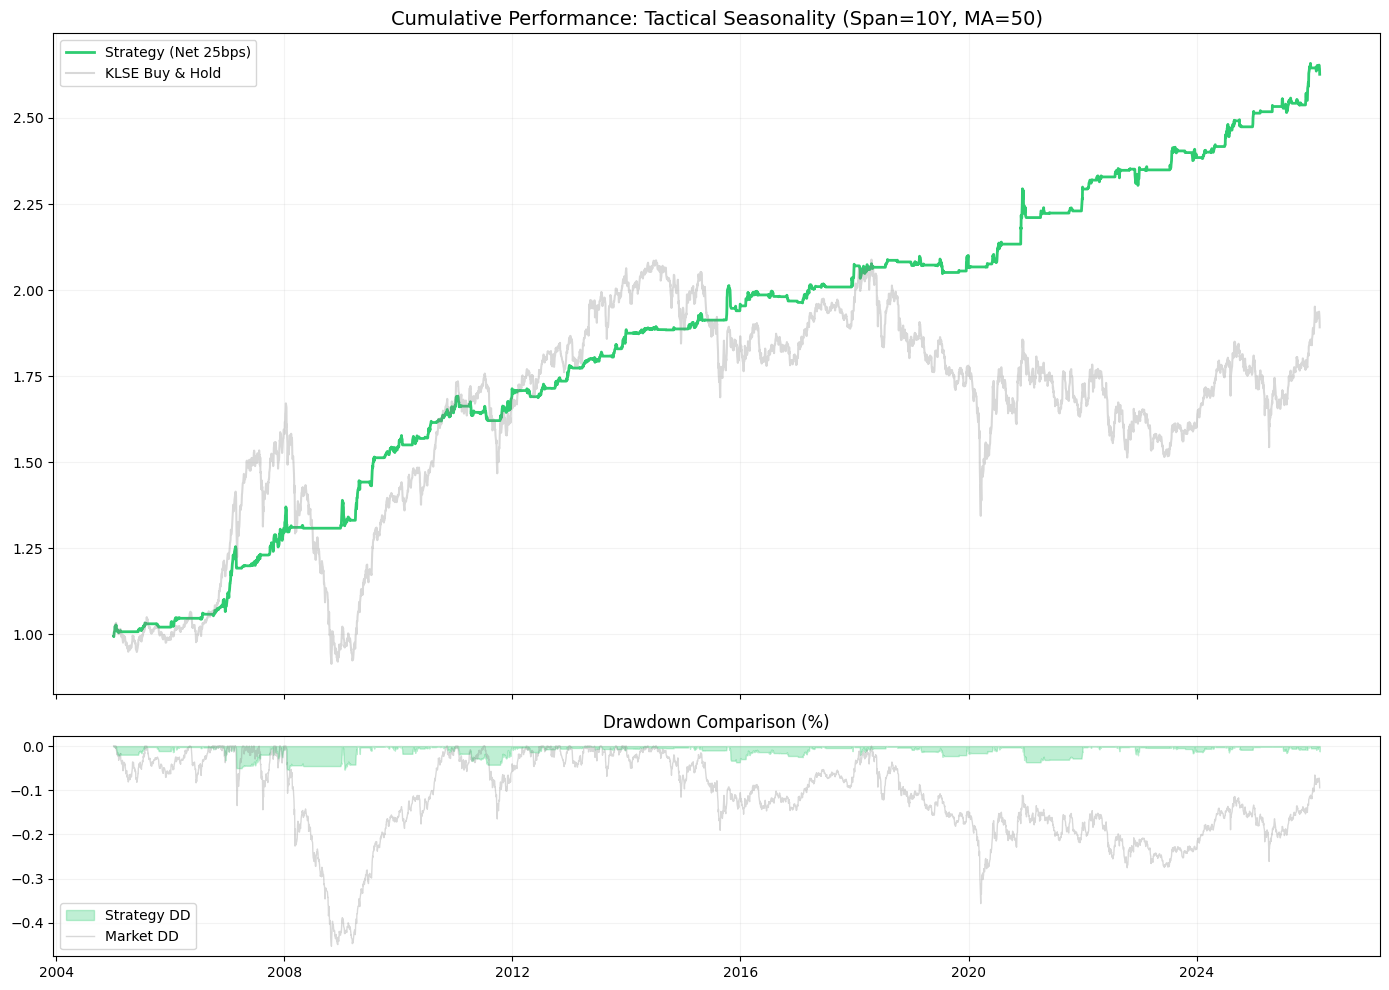

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_ewma_conviction_with_exit(data, span=10, scale_conviction=True, slippage_bps=25, trend_filter=100):
    df = data.copy()
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df['Market_Ret'] = df['Close'].pct_change()
    df['Month'] = df.index.month
    
    # 1. CALCULATE EXIT SIGNAL (50D TREND FILTER)
    df['MA'] = df['Close'].rolling(window=trend_filter).mean()
    df['Trend_Signal'] = np.where(df['Close'] > df['MA'], 1.0, 0.0)
    
    df['Target_Weight'] = 0.0 
    
    DATA_START_YEAR = df.index.year.min()
    TRADING_START_YEAR = DATA_START_YEAR + span 
    END_YEAR = df.index.year.max()
    
    print(f"🚀 Initializing Tactical Seasonal Strategy: {TRADING_START_YEAR} - {END_YEAR}")

    for year in range(TRADING_START_YEAR, END_YEAR + 1):
        # TRAIN
        train_data = df[df.index.year < year].copy()
        train_data['is_win'] = (train_data['Market_Ret'] > 0).astype(int)
        train_data['win_ret'] = np.where(train_data['Market_Ret'] > 0, train_data['Market_Ret'], np.nan)
        train_data['loss_ret'] = np.where(train_data['Market_Ret'] < 0, np.abs(train_data['Market_Ret']), np.nan)
        
        yearly_stats = train_data.groupby([train_data.index.year, 'Month']).agg(
            win_rate=('is_win', 'mean'),
            avg_win=('win_ret', 'mean'),
            avg_loss=('loss_ret', 'mean')
        ).unstack('Month')
        
        ewma_win_rate = yearly_stats['win_rate'].ewm(span=span).mean().iloc[-1]
        ewma_avg_win = yearly_stats['avg_win'].ewm(span=span).mean().iloc[-1]
        ewma_avg_loss = yearly_stats['avg_loss'].ewm(span=span).mean().iloc[-1]

        # TEST
        current_year_mask = df.index.year == year
        raw_sizes = {}
        for month in range(1, 13):
            p, avg_w, avg_l = ewma_win_rate[month], ewma_avg_win[month], ewma_avg_loss[month]
            if pd.isna(avg_l) or avg_l == 0: k_size = p 
            elif pd.isna(avg_w) or p == 0: k_size = 0
            else: k_size = p - ((1 - p) / (avg_w / avg_l))
            raw_sizes[month] = k_size if k_size > 0 else 0
            
        max_conviction = max(raw_sizes.values()) if raw_sizes.values() else 0
        
        for month in range(1, 13):
            size = raw_sizes[month] / max_conviction if (scale_conviction and max_conviction > 0) else min(raw_sizes[month], 1.0)
            month_mask = (df['Month'] == month) & current_year_mask
            df.loc[month_mask, 'Target_Weight'] = size * df.loc[month_mask, 'Trend_Signal']

    # --- METRICS & SLIPPAGE ---
    df['Weight_Change'] = df['Target_Weight'].diff().abs().fillna(0)
    slippage_dec = slippage_bps / 10000.0
    df['Strategy_Ret'] = (df['Target_Weight'] * df['Market_Ret']) - (df['Weight_Change'] * slippage_dec)

    trading_df = df[df.index.year >= TRADING_START_YEAR].copy()
    clean_rets = trading_df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        # Core Metrics
        sharpe = (clean_rets.mean() * 252) / (clean_rets.std() * np.sqrt(252))
        max_dd = ((cumulative_ret - cumulative_ret.cummax()) / cumulative_ret.cummax()).min() * 100
        total_slippage_drag = (trading_df['Weight_Change'] * slippage_dec).sum()
        
        active_days = clean_rets[trading_df['Target_Weight'] > 0]
        win_rate = (active_days > 0).mean() * 100
        avg_profit = active_days[active_days > 0].mean()
        avg_loss = abs(active_days[active_days < 0].mean())
        pl_ratio = avg_profit / avg_loss if avg_loss > 0 else np.inf

        print("-" * 45)
        print(f"      STRATEGY EDGE PROFILE ({TRADING_START_YEAR}-2026)")
        print("-" * 45)
        print(f"Total Return:      {(cumulative_ret.iloc[-1]-1)*100:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"Slippage Drag:     -{total_slippage_drag*100:.2f}% (at {slippage_bps} bps)")
        print("-" * 45)
        print(f"Win Rate:          {win_rate:.2f}%")
        print(f"Avg Daily Profit:  {avg_profit*100:.4f}%")
        print(f"Avg Daily Loss:    -{avg_loss*100:.4f}%")
        print(f"Profit/Loss Ratio: {pl_ratio:.2f}")
        print(f"Total Trade Count: {int((trading_df['Weight_Change'] > 0).sum())}")
        print("-" * 45)

        # PLOTTING
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

        # Equity Curve
        ax1.plot(cumulative_ret, label=f"Strategy (Net 25bps)", color='#2ecc71', lw=2)
        ax1.plot((1 + trading_df['Market_Ret']).cumprod(), label="KLSE Buy & Hold", alpha=0.3, color='gray')
        ax1.set_title(f"Cumulative Performance: Tactical Seasonality (Span={span}Y, MA={trend_filter})", fontsize=14)
        ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.15)

        # Drawdown Chart
        strategy_dd = (cumulative_ret - cumulative_ret.cummax()) / cumulative_ret.cummax()
        market_cum = (1 + trading_df['Market_Ret']).cumprod()
        market_dd = (market_cum - market_cum.cummax()) / market_cum.cummax()

        ax2.fill_between(strategy_dd.index, strategy_dd, 0, color='#2ecc71', alpha=0.3, label="Strategy DD")
        ax2.plot(market_dd, color='gray', alpha=0.3, lw=1, label="Market DD")
        ax2.set_title("Drawdown Comparison (%)", fontsize=12)
        ax2.legend(loc='lower left'); ax2.grid(True, alpha=0.15)

        plt.tight_layout(); plt.show()
        
    return trading_df, cumulative_ret

# Execute
ewma_df, ewma_cum = run_ewma_conviction_with_exit(data, span=10, slippage_bps=25, trend_filter=50)


--------------------------------------------------
      ANNUAL VOL-ADJUSTED ALPHA AUDIT
--------------------------------------------------
      Strategy_Ret  Market_Ret  Vol_Adj_Alpha
Date                                         
2005          2.08       -0.84           2.35
2006          7.46       21.83          -3.62
2007         19.13       31.82           5.13
2008          0.59      -39.33          10.05
2009         17.42       45.17          -7.01
2010          7.54       19.34          -0.33
2011          3.23        0.78           2.94
2012          3.95       10.34           0.11
2013          5.52       10.54           2.45
2014          0.41       -5.66           1.23
2015          3.78       -3.90           5.02
2016          0.48       -3.00           1.28
2017          5.44        9.45           1.18
2018          0.06       -5.91           1.37
2019         -0.52       -6.02           1.82
2020          7.29        2.42           6.65
2021          3.75       -3.67  

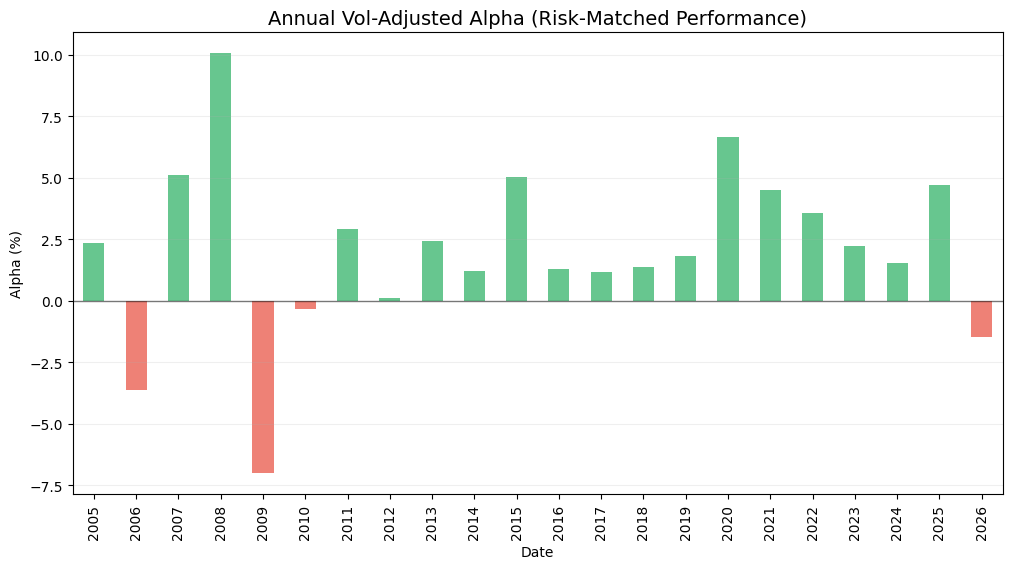

In [16]:
def calculate_vol_adjusted_alpha(df):
    # 1. Group by year and calculate returns and volatilities
    yearly_stats = df.groupby(df.index.year).apply(
        lambda x: pd.Series({
            'Strategy_Ret': (1 + x['Strategy_Ret']).prod() - 1,
            'Market_Ret': (1 + x['Market_Ret']).prod() - 1,
            'Strategy_Vol': x['Strategy_Ret'].std() * np.sqrt(252),
            'Market_Vol': x['Market_Ret'].std() * np.sqrt(252)
        })
    )

    # 2. Calculate Volatility Ratio (Beta-equivalent risk scaling)
    # If Strategy_Vol is 5% and Market_Vol is 15%, ratio is 0.33
    yearly_stats['Vol_Ratio'] = yearly_stats['Strategy_Vol'] / yearly_stats['Market_Vol']

    # 3. Calculate Vol-Adjusted Alpha
    # Strategy Return - (Market Return scaled down to Strategy's risk level)
    yearly_stats['Vol_Adj_Alpha'] = (
        yearly_stats['Strategy_Ret'] - (yearly_stats['Market_Ret'] * yearly_stats['Vol_Ratio'])
    ) * 100 # Convert to percentage

    # Clean up for display
    display_df = yearly_stats[['Strategy_Ret', 'Market_Ret', 'Vol_Adj_Alpha']].copy()
    display_df['Strategy_Ret'] *= 100
    display_df['Market_Ret'] *= 100
    
    print("-" * 50)
    print("      ANNUAL VOL-ADJUSTED ALPHA AUDIT")
    print("-" * 50)
    print(display_df.round(2))
    print("-" * 50)

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    colors = ['#27ae60' if x > 0 else '#e74c3c' for x in display_df['Vol_Adj_Alpha']]
    display_df['Vol_Adj_Alpha'].plot(kind='bar', color=colors, alpha=0.7)
    
    plt.title("Annual Vol-Adjusted Alpha (Risk-Matched Performance)", fontsize=14)
    plt.ylabel("Alpha (%)")
    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

    return display_df

# Execute
vol_alpha_df = calculate_vol_adjusted_alpha(ewma_df)


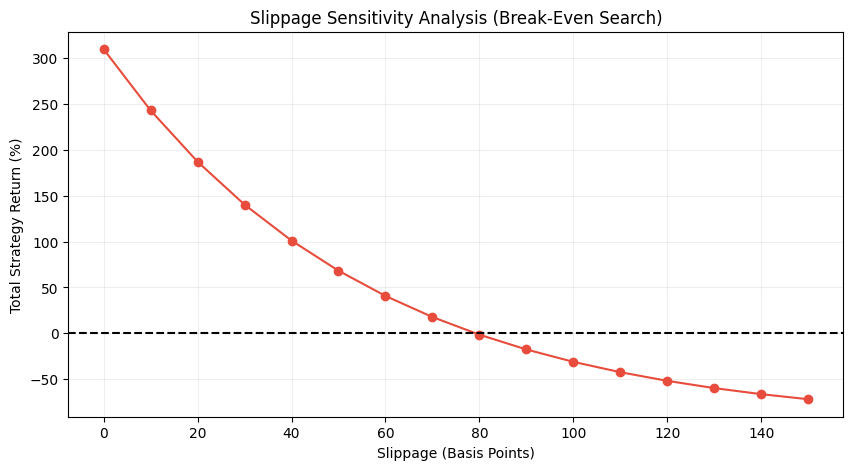

🛑 Strategy breaks even at approximately 80 bps.


,Slippage_Bps,Total_Return
0,0,309.815439
1,10,243.063938
2,20,187.149543
3,30,140.318615
4,40,101.100353
5,50,68.261324
6,60,40.767284
7,70,17.751118
8,80,-1.514083
9,90,-17.637612


In [17]:
def calculate_slippage_tolerance(trading_df, max_bps=150, step=10):
    results = []
    # turnover = sum of all absolute weight changes
    turnover = trading_df['Weight_Change'].sum()
    
    # We use the 'Gross Return' (Market_Ret * Weight) as the starting point
    gross_rets = trading_df['Target_Weight'] * trading_df['Market_Ret']
    
    for bps in range(0, max_bps + 1, step):
        slip_dec = bps / 10000.0
        net_rets = gross_rets - (trading_df['Weight_Change'] * slip_dec)
        total_ret = (1 + net_rets).prod() - 1
        
        results.append({'Slippage_Bps': bps, 'Total_Return': total_ret * 100})
    
    sensitivity_df = pd.DataFrame(results)
    
    # Find Break-Even
    break_even = sensitivity_df.loc[sensitivity_df['Total_Return'] <= 0, 'Slippage_Bps'].min()
    
    plt.figure(figsize=(10, 5))
    plt.plot(sensitivity_df['Slippage_Bps'], sensitivity_df['Total_Return'], marker='o', color='#e74c3c')
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Slippage Sensitivity Analysis (Break-Even Search)")
    plt.xlabel("Slippage (Basis Points)")
    plt.ylabel("Total Strategy Return (%)")
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"🛑 Strategy breaks even at approximately {break_even} bps.")
    return sensitivity_df

# Run it using the 'ewma_df' from your previous execution
sensitivity_results = calculate_slippage_tolerance(ewma_df)
sensitivity_results


----------------------------------------
      DISTRIBUTION ANALYSIS (ACTIVE DAYS)
----------------------------------------
Skewness:         0.1093
Excess Kurtosis:  10.8113
JB Statistic:     9778.37
p-value:          0.0000e+00
----------------------------------------
Result: REJECT Null Hypothesis (Returns are NOT Normal)
Note: Fat tails or skewness detected. Standard VaR might underestimate risk.


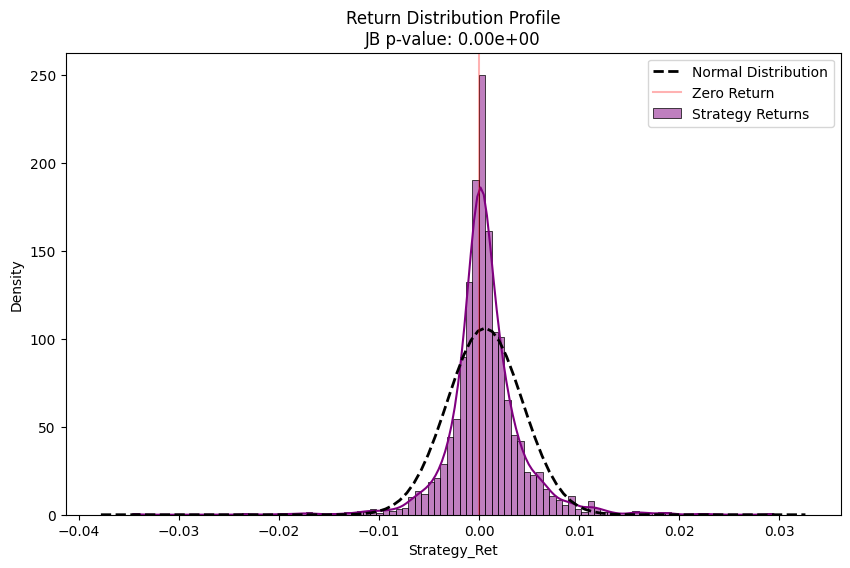

In [18]:
from scipy.stats import skew, kurtosis, jarque_bera
import seaborn as sns

# 1. Filter for days where we were actually in the market (Exposure > 0)
# This gives a true representation of the strategy's active "DNA"
active_returns = ewma_df[ewma_df['Target_Weight'] > 0]['Strategy_Ret'].dropna()

# 2. Calculate the Moments
s = skew(active_returns)
k = kurtosis(active_returns)  # Fisher’s definition (Excess Kurtosis)
jb_stat, p_value = jarque_bera(active_returns)

print("-" * 40)
print(f"      DISTRIBUTION ANALYSIS (ACTIVE DAYS)")
print("-" * 40)
print(f"Skewness:         {s:.4f}")
print(f"Excess Kurtosis:  {k:.4f}")
print(f"JB Statistic:     {jb_stat:.2f}")
print(f"p-value:          {p_value:.4e}")
print("-" * 40)

# 3. Interpret the Result
if p_value < 0.05:
    print("Result: REJECT Null Hypothesis (Returns are NOT Normal)")
    print("Note: Fat tails or skewness detected. Standard VaR might underestimate risk.")
else:
    print("Result: FAIL TO REJECT Null Hypothesis (Returns appear Normal)")

# 4. Visualizing the "Shape" with a Normal Overlay
plt.figure(figsize=(10, 6))
sns.histplot(active_returns, kde=True, color='purple', bins=100, stat="density", label="Strategy Returns")

# Overlay a theoretical normal distribution for comparison
from scipy.stats import norm
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, active_returns.mean(), active_returns.std())
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label="Normal Distribution")

plt.axvline(0, color='red', linestyle='-', alpha=0.3, label="Zero Return")
plt.title(f"Return Distribution Profile\nJB p-value: {p_value:.2e}")
plt.legend()
plt.show()


In [19]:
from scipy.stats import norm

def calculate_cornish_fisher_var(returns, confidence_level=0.95):
    # 1. Basic Stats
    mu = returns.mean()
    sigma = returns.std()
    s = returns.skew()
    k = returns.kurt() # Excess Kurtosis
    
    # 2. Standard Z-score for the given confidence level (e.g., 1.645 for 95%)
    z = norm.ppf(1 - confidence_level)
    
    # 3. Cornish-Fisher Adjustment
    z_cf = (z + 
            (1/6) * (z**2 - 1) * s + 
            (1/24) * (z**3 - 3*z) * k - 
            (1/36) * (2*z**3 - 5*z) * (s**2))
    
    # 4. Calculate VaR
    standard_var = mu + z * sigma
    cf_var = mu + z_cf * sigma
    
    return standard_var, cf_var

# Execute
std_var, cf_var = calculate_cornish_fisher_var(active_returns)

print("-" * 40)
print(f"      RISK ANALYSIS (VaR 95%)")
print("-" * 40)
print(f"Standard VaR:        {std_var*100:.4f}%")
print(f"Cornish-Fisher VaR:  {cf_var*100:.4f}%")
print(f"Risk Adjustment:     {((cf_var/std_var)-1)*100:.2f}% higher risk detected")
print("-" * 40)


----------------------------------------
      RISK ANALYSIS (VaR 95%)
----------------------------------------
Standard VaR:        -0.5596%
Cornish-Fisher VaR:  -0.4656%
Risk Adjustment:     -16.80% higher risk detected
----------------------------------------


      STRATEGY REGIME STRESS TEST        

--- 1. PERFORMANCE BY ERA ---
          Strat Return Mkt Return  Strat Sharpe
Era                                            
2005-2009        54.4%      40.3%          1.63
2010-2014        22.3%      38.4%          1.39
2015-2019         9.5%      -9.8%          0.68
2020-2024        22.0%       3.4%          1.27
2025-2029         4.3%       4.5%          1.34


--- 2. PERFORMANCE BY MARKET STATE ---
                      Months in Regime Strat Win Rate Strat Avg Monthly Ret
Regime                                                                     
Bear Month (Mkt < 0)               112           8.9%                -0.13%
Bull Month (Mkt > 0)               142          64.8%                 0.80%


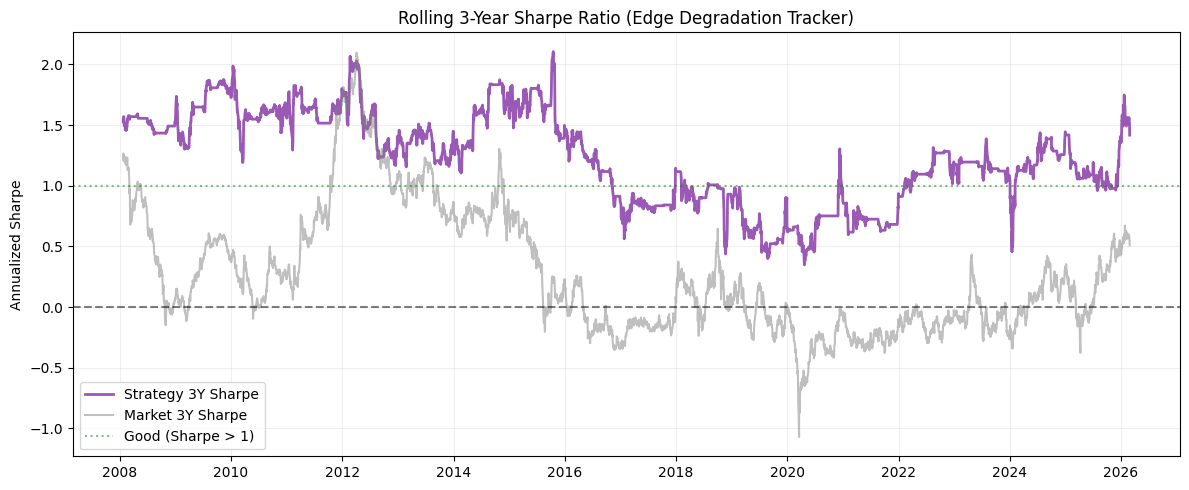

In [20]:
def analyze_strategy_regimes(trading_df):
    """
    Takes the trading_df containing 'Strategy_Ret' and 'Market_Ret' 
    and breaks performance down by time eras and market regimes.
    """
    df = trading_df.copy()
    
    # Ensure we drop any NaN values from the warmup period
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna(subset=['Strategy_Ret', 'Market_Ret'])

    
    print("=========================================")
    print("      STRATEGY REGIME STRESS TEST        ")
    print("=========================================\n")

    # ---------------------------------------------------------
    # TEST 1: CHRONOLOGICAL ERAS (5-Year Blocks)
    # ---------------------------------------------------------
    print("--- 1. PERFORMANCE BY ERA ---")
    df['Year'] = df.index.year
    
    # Create 5-year bins
    min_year = df['Year'].min()
    max_year = df['Year'].max()
    bins = range(min_year, max_year + 6, 5)
    labels = [f"{y}-{y+4}" for y in bins[:-1]]
    df['Era'] = pd.cut(df['Year'], bins=bins, labels=labels, right=False)

    era_metrics = []
    for era, group in df.groupby('Era', observed=True):
        if len(group) == 0: continue
        
        strat_ret = (1 + group['Strategy_Ret']).cumprod().iloc[-1] - 1
        mkt_ret = (1 + group['Market_Ret']).cumprod().iloc[-1] - 1
        
        # Annualized Sharpe
        strat_sharpe = (group['Strategy_Ret'].mean() * 252) / (group['Strategy_Ret'].std() * np.sqrt(252)) if group['Strategy_Ret'].std() > 0 else 0
        
        era_metrics.append({
            'Era': era,
            'Strat Return': f"{strat_ret * 100:.1f}%",
            'Mkt Return': f"{mkt_ret * 100:.1f}%",
            'Strat Sharpe': round(strat_sharpe, 2)
        })
        
    era_df = pd.DataFrame(era_metrics).set_index('Era')
    print(era_df.to_string())
    print("\n")

    # ---------------------------------------------------------
    # TEST 2: BULL VS. BEAR MARKET REGIMES
    # ---------------------------------------------------------
    print("--- 2. PERFORMANCE BY MARKET STATE ---")
    
    # Define a "Bull Month" as a month where the Market Return was > 0
    # We aggregate to monthly to reduce daily noise
    monthly_rets = df.resample('ME').apply({
        'Strategy_Ret': lambda x: (1+x).prod() - 1,
        'Market_Ret': lambda x: (1+x).prod() - 1
    })
    
    monthly_rets['Market_Regime'] = np.where(monthly_rets['Market_Ret'] > 0, 'Bull Month (Mkt > 0)', 'Bear Month (Mkt < 0)')
    
    regime_metrics = []
    for regime, group in monthly_rets.groupby('Market_Regime'):
        win_rate = (group['Strategy_Ret'] > 0).mean() * 100
        avg_ret = group['Strategy_Ret'].mean() * 100
        
        regime_metrics.append({
            'Regime': regime,
            'Months in Regime': len(group),
            'Strat Win Rate': f"{win_rate:.1f}%",
            'Strat Avg Monthly Ret': f"{avg_ret:.2f}%"
        })
        
    regime_df = pd.DataFrame(regime_metrics).set_index('Regime')
    print(regime_df.to_string())

    # ---------------------------------------------------------
    # VISUALIZATION: ROLLING 3-YEAR SHARPE RATIO
    # ---------------------------------------------------------
    # A rolling Sharpe shows exactly when the edge degrades
    rolling_window = 252 * 3 # 3 Years
    
    df['Roll_Strat_Sharpe'] = (df['Strategy_Ret'].rolling(rolling_window).mean() * 252) / \
                              (df['Strategy_Ret'].rolling(rolling_window).std() * np.sqrt(252))
                              
    df['Roll_Mkt_Sharpe'] = (df['Market_Ret'].rolling(rolling_window).mean() * 252) / \
                            (df['Market_Ret'].rolling(rolling_window).std() * np.sqrt(252))

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['Roll_Strat_Sharpe'], label='Strategy 3Y Sharpe', color='#9b59b6', lw=2)
    plt.plot(df.index, df['Roll_Mkt_Sharpe'], label='Market 3Y Sharpe', color='gray', alpha=0.5)
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.axhline(1, color='green', linestyle=':', alpha=0.5, label='Good (Sharpe > 1)')
    
    plt.title("Rolling 3-Year Sharpe Ratio (Edge Degradation Tracker)")
    plt.ylabel("Annualized Sharpe")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

analyze_strategy_regimes(ewma_df)


In [21]:
def calculate_intra_day_pain(df):
    # 1. Calculate the 'Worst Case' Daily Return using Low prices
    # We assume you entered at the Previous Close and experienced the Day's Low
    df['Intra_Day_Low_Ret'] = (df['Low'] - df['Close'].shift(1)) / df['Close'].shift(1)
    
    # 2. Strategy's 'Shadow' Drawdown
    # This is what your account balance felt like at the scariest moment of the day
    df['Shadow_Ret'] = df['Target_Weight'] * df['Intra_Day_Low_Ret']
    
    # 3. Compare the 'Clean' Drawdown vs. the 'Painful' Drawdown
    strategy_cum = (1 + df['Strategy_Ret']).cumprod()
    clean_dd = (strategy_cum - strategy_cum.cummax()) / strategy_cum.cummax()
    
    # The 'Shadow' Equity is the last high * (1 + worst intraday move)
    shadow_dd = (strategy_cum.shift(1) * (1 + df['Shadow_Ret']) - strategy_cum.cummax()) / strategy_cum.cummax()
    
    max_clean_dd = clean_dd.min() * 100
    max_shadow_dd = shadow_dd.min() * 100
    
    print("-" * 45)
    print("      METRIC 1: INTRA-DAY PAIN AUDIT")
    print("-" * 45)
    print(f"Reported Max DD (Close):  {max_clean_dd:.2f}%")
    print(f"Actual Shadow Max DD (Low): {max_shadow_dd:.2f}%")
    print(f"The 'Pain' Multiple:      {max_shadow_dd / max_clean_dd:.2f}x")
    print("-" * 45)
    
    if abs(max_shadow_dd) > 10:
        print("⚠️ WARNING: Your -5% Max DD is a 'Smoothing Mirage'.")
        print("In a real account, you would have been down >10% intraday.")
    
    return shadow_dd

shadow_dd = calculate_intra_day_pain(ewma_df)


---------------------------------------------
      METRIC 1: INTRA-DAY PAIN AUDIT
---------------------------------------------
Reported Max DD (Close):  -5.33%
Actual Shadow Max DD (Low): -8.18%
The 'Pain' Multiple:      1.53x
---------------------------------------------


In [22]:
def calculate_capacity_decay(df, base_slip_bps=25):
    # We test 3 'Fund Sizes': Small ($100k), Medium ($1M), Large ($10M)
    # We scale slippage linearly with 'size' (a simplified impact model)
    sizes = {'Retail': 1, 'Pro': 3, 'Institutional': 6} # Multipliers for slippage
    
    results = {}
    gross_rets = df['Target_Weight'] * df['Market_Ret']
    
    for label, mult in sizes.items():
        slip_bps = base_slip_bps * mult
        slip_dec = slip_bps / 10000.0
        net_rets = gross_rets - (df['Weight_Change'] * slip_dec)
        total_ret = (1 + net_rets).prod() - 1
        results[label] = (total_ret * 100, slip_bps)

    print("-" * 45)
    print("      METRIC 2: CAPACITY & IMPACT WALL")
    print("-" * 45)
    for label, (ret, bps) in results.items():
        print(f"{label:15} | Slippage: {bps:3} bps | Total Ret: {ret:6.2f}%")
    print("-" * 45)
    
    drag_diff = results['Retail'][0] - results['Institutional'][0]
    print(f"⚠️ Capacity Drag: You lose {drag_diff:.2f}% of total return scaling to Institutional size.")
    
    return results
calculate_capacity_decay(ewma_df)


---------------------------------------------
      METRIC 2: CAPACITY & IMPACT WALL
---------------------------------------------
Retail          | Slippage:  25 bps | Total Ret: 162.70%
Pro             | Slippage:  75 bps | Total Ret:   7.69%
Institutional   | Slippage: 150 bps | Total Ret: -71.90%
---------------------------------------------
⚠️ Capacity Drag: You lose 234.60% of total return scaling to Institutional size.


{'Retail': (np.float64(162.69662831679886), 25),
 'Pro': (np.float64(7.690245867187473), 75),
 'Institutional': (np.float64(-71.89960189877273), 150)}

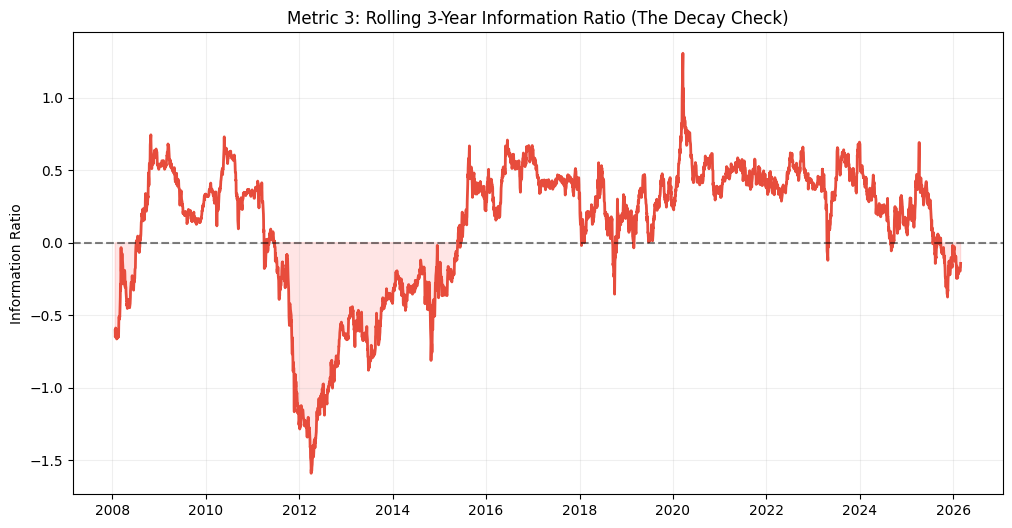

---------------------------------------------
      METRIC 3: REGIME DECAY AUDIT
---------------------------------------------
Peak 3-Year IR:     1.31
Current 2026 IR:    -0.14
Edge Retention:     -10.91%
---------------------------------------------
⚠️ DANGER: The edge is decaying. You are relying on 2008 data to justify a 2026 trade.


In [23]:
def calculate_rolling_edge_decay(df, window_years=1):
    # Calculate daily excess returns (Strategy - Market)
    df['Excess_Ret'] = df['Strategy_Ret'] - df['Market_Ret']
    
    # Rolling 3-Year Mean and Std of Excess Returns
    days = 252 * window_years
    rolling_alpha = df['Excess_Ret'].rolling(window=days).mean() * 252
    rolling_vol = df['Excess_Ret'].rolling(window=days).std() * np.sqrt(252)
    
    # Information Ratio: How much alpha per unit of active risk?
    df['Rolling_IR'] = rolling_alpha / rolling_vol
    
    plt.figure(figsize=(12, 6))
    plt.plot(df['Rolling_IR'], color='#e74c3c', lw=2)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f"Metric 3: Rolling {window_years}-Year Information Ratio (The Decay Check)")
    plt.ylabel("Information Ratio")
    plt.fill_between(df.index, df['Rolling_IR'], 0, where=(df['Rolling_IR'] < 0), color='red', alpha=0.1)
    plt.grid(True, alpha=0.2)
    plt.show()
    
    current_ir = df['Rolling_IR'].iloc[-1]
    peak_ir = df['Rolling_IR'].max()
    
    print("-" * 45)
    print(f"      METRIC 3: REGIME DECAY AUDIT")
    print("-" * 45)
    print(f"Peak 3-Year IR:     {peak_ir:.2f}")
    print(f"Current 2026 IR:    {current_ir:.2f}")
    print(f"Edge Retention:     {(current_ir/peak_ir)*100:.2f}%")
    print("-" * 45)
    
    if current_ir < 0.5:
        print("⚠️ DANGER: The edge is decaying. You are relying on 2008 data to justify a 2026 trade.")
calculate_rolling_edge_decay(ewma_df, window_years=3)


--- KELLY L/S SEASONAL RISK REPORT ---
Total Return:      136.86%
Annualized Sharpe: 0.5663
Max Drawdown:      -16.30%
--- EXPOSURE ANALYSIS ---
Max Long Size:     82.3%
Max Short Size:    25.0%


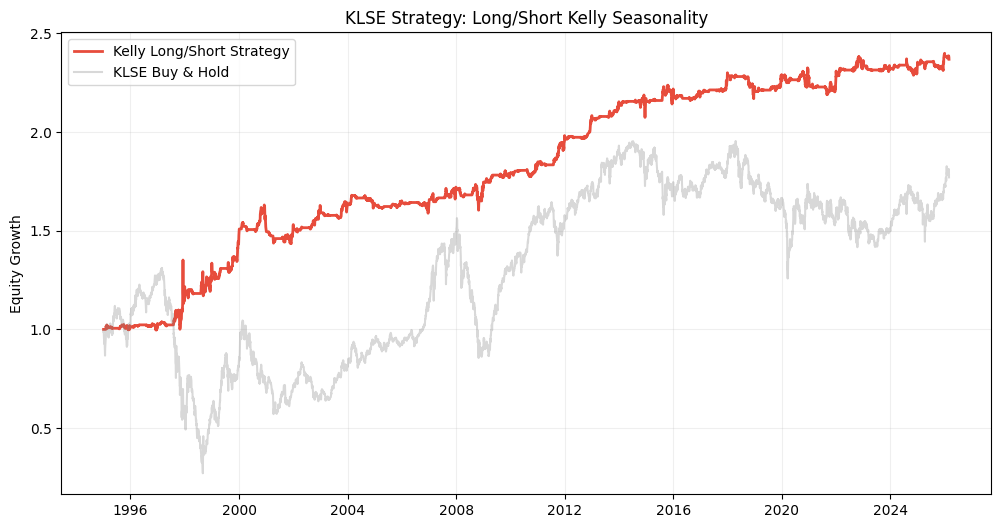

In [24]:
def run_seasonal_backtest_kelly_ls(data, seasonality_analysis):
    df = data.copy()
    
    # 1. Prepare seasonality and monthly stats for Win/Loss Ratio (R)
    seasonality_analysis.index = seasonality_analysis.index.astype(int)
    df['Month'] = df.index.month
    df['Market_Ret'] = df['Close'].pct_change()
    
    # Calculate historical Win/Loss Ratio per month
    monthly_stats = {}
    for m in range(1, 13):
        m_rets = df[df['Month'] == m]['Market_Ret'].dropna()
        pos_rets = m_rets[m_rets > 0].mean()
        neg_rets = abs(m_rets[m_rets < 0].mean())
        # Long R: Avg Win / Avg Loss
        # Short R: Avg Loss / Avg Win (since a market drop is a win for a short)
        long_r = pos_rets / neg_rets if neg_rets != 0 else 1.0
        short_r = neg_rets / pos_rets if pos_rets != 0 else 1.0
        monthly_stats[m] = {'long_r': long_r, 'short_r': short_r}

    # 2. Map Kelly Components
    df['W_long'] = df['Month'].map(seasonality_analysis['Win Rate (%)']) / 100.0
    df['W_short'] = 1 - df['W_long']
    
    df['R_long'] = df['Month'].apply(lambda x: monthly_stats[x]['long_r'])
    df['R_short'] = df['Month'].apply(lambda x: monthly_stats[x]['short_r'])
    
    # 3. Kelly Formulas
    # K_long = W - ((1-W)/R)
    df['Kelly_Long'] = df['W_long'] - ((1 - df['W_long']) / df['R_long'])
    # K_short = W_down - ((1-W_down)/R_down)
    df['Kelly_Short'] = df['W_short'] - ((1 - df['W_short']) / df['R_short'])
    
    # Use Half-Kelly for both
    k_long_arr = (df['Kelly_Long'] * 1.0).values.flatten()
    k_short_arr = (df['Kelly_Short'] * 1.0).values.flatten()
    w_long_arr = df['W_long'].values.flatten()
    
    # 4. Long/Short Execution Logic
    # Condition Long: Win Rate > 55% AND Kelly > 0
    # Condition Short: Win Rate < 45% AND Kelly > 0 (Size will be negative)
    
    df['Position_Size'] = 0.0
    # Apply Longs
    df.loc[(w_long_arr > 0.55) & (k_long_arr > 0), 'Position_Size'] = np.clip(k_long_arr[(w_long_arr > 0.55) & (k_long_arr > 0)], 0, 1.0)
    # Apply Shorts (Negative size)
    df.loc[(w_long_arr < 0.45) & (k_short_arr > 0), 'Position_Size'] = -np.clip(k_short_arr[(w_long_arr < 0.45) & (k_short_arr > 0)], 0, 1.0)

    # 5. Calculate Strategy Returns
    df['Strategy_Ret'] = df['Position_Size'].shift(1) * df['Market_Ret']
    
    # 6. Metrics & Performance
    clean_rets = df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        vol = clean_rets.std() * np.sqrt(252)
        sharpe = (clean_rets.mean() * 252) / vol if vol != 0 else 0
        
        rolling_max = cumulative_ret.cummax()
        drawdowns = (cumulative_ret - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        
        print(f"--- KELLY L/S SEASONAL RISK REPORT ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"--- EXPOSURE ANALYSIS ---")
        print(f"Max Long Size:     {df['Position_Size'].max()*100:.1f}%")
        print(f"Max Short Size:    {abs(df['Position_Size'].min())*100:.1f}%")
        
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label="Kelly Long/Short Strategy", color='#e74c3c', linewidth=2)
        plt.plot((1 + df['Market_Ret'].dropna()).cumprod(), label="KLSE Buy & Hold", alpha=0.3, color='gray')
        plt.title("KLSE Strategy: Long/Short Kelly Seasonality")
        plt.ylabel("Equity Growth")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    else:
        print("Error: No trade data generated.")

# Run it
run_seasonal_backtest_kelly_ls(data, seasonality_analysis)


--- DYNAMIC SEASONAL RISK REPORT ---
Total Return:      270.04%
Annualized Sharpe: 0.5718
Max Drawdown:      -21.79%
--- SIZING ANALYSIS ---
Max Position Size: 90.3%
Min Position Size: 51.6% (Active Trades Only)


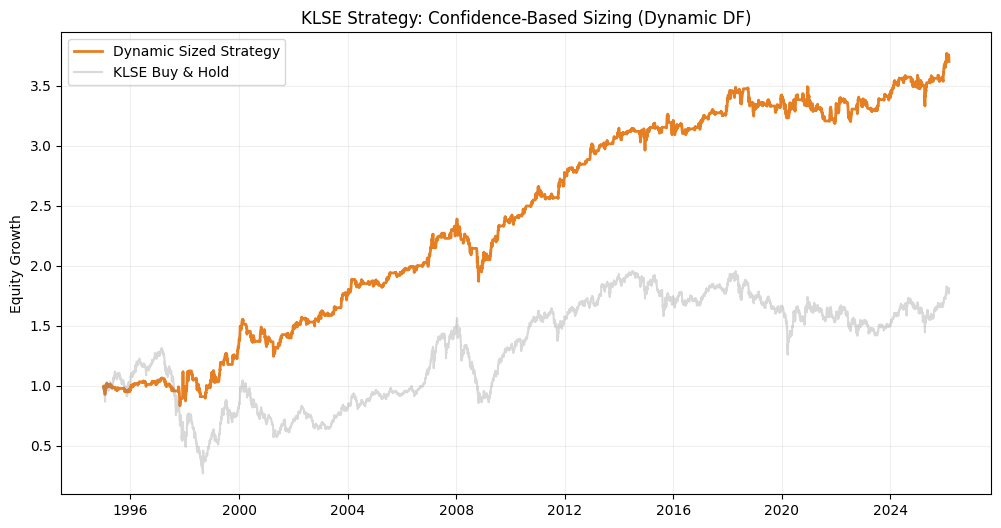

In [25]:
def run_seasonal_backtest_dynamic(data, seasonality_analysis):
    df = data.copy()
    
    # 1. Clean the seasonality_analysis
    seasonality_analysis.index = seasonality_analysis.index.astype(int)
    
    # 2. Add Time/Trend Features
    df['Month'] = df.index.month
    
    # 3. Map values from your seasonality_analysis DF
    df['Win_Rate'] = df['Month'].map(seasonality_analysis['Win Rate (%)'])
    
    # 4. EXECUTION LOGIC
    # Using the 'values' hammer for alignment safety
    win_rate_arr = df['Win_Rate'].values.flatten()
    
    # Simple sizing: Position Size = Win Rate % (if > 50%)
    df['Position_Size'] = np.where(
        (win_rate_arr > 50),
        (win_rate_arr / 100.0), 
        0
    )

    # 5. CALCULATE RETURNS
    df['Market_Ret'] = df['Close'].pct_change()
    df['Strategy_Ret'] = df['Position_Size'].shift(1) * df['Market_Ret']
    
    # 6. PERFORMANCE SUMMARY
    clean_rets = df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        # --- RISK METRICS ---
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        vol = clean_rets.std() * np.sqrt(252)
        sharpe = (clean_rets.mean() * 252) / vol if vol != 0 else 0
        
        # Max Drawdown
        rolling_max = cumulative_ret.cummax()
        drawdowns = (cumulative_ret - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        
        # Sizing Extremes
        max_size = df['Position_Size'].max()
        active_sizes = df[df['Position_Size'] > 0]['Position_Size']
        min_size = active_sizes.min() if not active_sizes.empty else 0

        print(f"--- DYNAMIC SEASONAL RISK REPORT ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"--- SIZING ANALYSIS ---")
        print(f"Max Position Size: {max_size*100:.1f}%")
        print(f"Min Position Size: {min_size*100:.1f}% (Active Trades Only)")
        
        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label="Dynamic Sized Strategy", color='#e67e22', linewidth=2)
        plt.plot((1 + df['Market_Ret'].dropna()).cumprod(), label="KLSE Buy & Hold", alpha=0.3, color='gray')
        plt.title("KLSE Strategy: Confidence-Based Sizing (Dynamic DF)")
        plt.ylabel("Equity Growth")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    else:
        print("Error: No trade data generated.")

# Run it
run_seasonal_backtest_dynamic(data, seasonality_analysis)


In [26]:
# --- THE CORRECTED PIPELINE ---

# 1. Stay in DAILY frequency (Don't resample to 'ME')
ticker = "^KLSE"
data = yf.download(ticker, start="2005-01-01", end="2026-03-01")
prices = data['Close'].ffill() # This stays at ~5,300 rows

# 2. Log transform the DAILY prices
log_prices = np.log(prices)

# 3. Apply STL with a DAILY Period
# period=252 represents one trading year in daily data
stl = STL(log_prices, period=252, robust=True)
res = stl.fit()

# 4. Now run your 'industrial_april_analysis'
# It will now find ~400+ days for each week across the 21-year history!

def industrial_april_analysis(prices, seasonal_component):
    # 2. Calculate Daily Returns on the FULL series first
    # If you do pct_change() after filtering, you compare April 2025 to April 2024!
    full_df = pd.DataFrame({
        'Price': prices.squeeze(),
        'Seasonal': seasonal_component.squeeze()
    })
    full_df['Daily_Ret'] = full_df['Price'].pct_change()
    
    # 3. NOW Filter for all Aprils
    df_april = full_df[full_df.index.month == 4].copy()
    
    if df_april.empty:
        return "ERROR: No April data found. Check if your index is actually Datetime."

    # 4. Week Logic
    df_april['Day'] = df_april.index.day
    def get_week(day):
        if day <= 7: return 'W1'
        if day <= 14: return 'W2'
        if day <= 21: return 'W3'
        return 'W4'
    df_april['Week'] = df_april['Day'].apply(get_week)
    
    # 5. Aggregate with 'observed=False' to force all categories to show
    res = df_april.groupby('Week', observed=False).agg({
        'Day': 'count',
        'Seasonal': 'mean',
        'Daily_Ret': lambda x: (x > 0).mean() * 100
    })
    
    res.columns = ['Sample_Size_Days', 'Seasonal_Strength (%)', 'Win_Rate (%)']
    
    # Convert log strength to % impact
    res['Seasonal_Strength (%)'] = (np.exp(res['Seasonal_Strength (%)']) - 1) * 100
    
    return res.round(2)

# IMPORTANT: Make sure you are passing the ORIGINAL prices, not a tail!
full_april_stats = industrial_april_analysis(prices, res.seasonal)
full_april_stats


[*********************100%***********************]  1 of 1 completed


,Sample_Size_Days,Seasonal_Strength (%),Win_Rate (%)
Week,,,
W1,104,0.35,60.58
W2,101,0.49,49.50
W3,102,0.58,59.80
W4,130,0.51,55.38


In [27]:
# 1. Calculate Daily Returns
# Assuming 'df' is your original daily price dataframe
data['Returns'] = data['Close'].pct_change() * 100

# 2. Extract Day Name and Number (0=Monday, 4=Friday)
data['Day_Name'] = data.index.day_name()
data['Day_Num'] = data.index.dayofweek

# 3. Calculate Mean Return and Win Rate by Day
dow_stats = data.groupby(['Day_Num', 'Day_Name'])['Returns'].agg([
    ('Mean Return (%)', 'mean'),
    ('Win Rate (%)', lambda x: (x > 0).mean() * 100),
    ('Volatility (%)', 'std')
]).reset_index()

print(dow_stats.round(3))


   Day_Num   Day_Name  Mean Return (%)  Win Rate (%)  Volatility (%)
0        0     Monday           -0.068        48.847           0.852
1        1    Tuesday            0.040        53.705           0.671
2        2  Wednesday            0.014        51.374           0.698
3        3   Thursday            0.042        52.153           0.698
4        4     Friday            0.043        53.751           0.707


In [28]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- THE FIX: Synchronize the data first ---
# Create a temporary dataframe with only the columns we need and drop rows with NaNs (like the first row of Returns)
clean_data = data[['Returns', 'Day_Num']].dropna()

# 1. Run ANOVA
# Use the synchronized 'clean_data' instead of 'data'
model = ols('Returns ~ C(Day_Num)', data=clean_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Results:")
print(anova_table)

# 2. Post-hoc tests
# Use .iloc[0] to safely access the p-value from the first row of the ANOVA table
p_val = anova_table['PR(>F)'].iloc[0]

if p_val < 0.05:
    print(f"\nSignificant differences found (p={p_val:.4f})! Running Post-hoc tests...")
    # Pass the synchronized columns directly
    tukey = pairwise_tukeyhsd(endog=clean_data['Returns'],
                             groups=clean_data['Day_Num'],
                             alpha=0.05)
    print(tukey)
else:
    print(f"\nNo statistically significant difference (p={p_val:.4f}) between days at the 95% confidence level.")


ANOVA Results:
                 sum_sq      df         F    PR(>F)
C(Day_Num)     9.064916     4.0  4.287819  0.001827
Residual    2739.356449  5183.0       NaN       NaN

Significant differences found (p=0.0018)! Running Post-hoc tests...
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.1079 0.0074  0.0199 0.1958   True
     0      2    0.082 0.0797 -0.0057 0.1696  False
     0      3   0.1095 0.0061  0.0217 0.1974   True
     0      4    0.111  0.005  0.0233 0.1987   True
     1      2  -0.0259 0.9262 -0.1126 0.0608  False
     1      3   0.0017    1.0 -0.0852 0.0886  False
     1      4   0.0031    1.0 -0.0836 0.0899  False
     2      3   0.0276 0.9084  -0.059 0.1141  False
     2      4    0.029 0.8907 -0.0574 0.1154  False
     3      4   0.0015    1.0 -0.0852 0.0881  False
---------------------------------------------------


In [29]:
import ee
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# 1. INITIALIZE & CONFIGURATION
ee.Initialize(project='numeric-marker-490315-v8')

# The "Big Three" Malaysian Export Hubs
MY_PORTS = {
    "Port Klang": {"lon": 101.326, "lat": 2.969},
    "Tanjung Pelepas (PTP)": {"lon": 103.545, "lat": 1.363},
    "Penang Port": {"lon": 100.370, "lat": 5.394}
}


In [30]:

def get_aggregated_data(ticker="USDMYR=X", start='2015-01-01', end='2026-03-15'):
    print(f"--- FETCHING AGGREGATED NATIONAL PORT DATA ---")
    
    # 1. Fetch Currency Data
    stock = yf.download(ticker, start=start, end=end)
    if isinstance(stock.columns, pd.MultiIndex): stock.columns = stock.columns.get_level_values(0)
    stock = stock[['Close']].copy()
    stock.index = pd.to_datetime(stock.index).as_unit('ns')
    
    # 2. Loop through ports and fetch SAR data
    radar_dfs = []
    
    for port_name, coords in MY_PORTS.items():
        print(f"Extracting SAR data for {port_name}...")
        aoi = ee.Geometry.Point([coords['lon'], coords['lat']]).buffer(5000).bounds()
        col = (ee.ImageCollection('COPERNICUS/S1_GRD')
               .filterBounds(aoi).filterDate(start, end).sort('system:time_start'))

        def extract_radar_stats(img):
            date = img.date().format('YYYY-MM-dd')
            main_band = ee.String(ee.Algorithms.If(img.bandNames().contains('VV'), 'VV', img.bandNames().get(0)))
            stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi, scale=100)
            return ee.Feature(None, {'Date': date, f'{port_name}_dB': stats.get(main_band)})

        raw_results = col.map(extract_radar_stats).getInfo()
        
        # Clean and format the data for this specific port
        points = [{'Date': pd.to_datetime(f['properties']['Date']), 
                   port_name: f['properties'][f'{port_name}_dB']} 
                  for f in raw_results['features'] if f['properties'][f'{port_name}_dB'] is not None]
        
        df_port = pd.DataFrame(points).drop_duplicates('Date').set_index('Date')
        df_port.index = pd.to_datetime(df_port.index).as_unit('ns')
        radar_dfs.append(df_port)
    
    # 3. Combine all port data
    print("\nMerging and calculating National Aggregate...")
    combined_radar = pd.concat(radar_dfs, axis=1).sort_index()
    
    # Interpolate missing days (since satellites pass over different ports on different days)
    combined_radar = combined_radar.interpolate(method='time').dropna()
    
    # CALCULATE THE AGGREGATE SIGNAL (Mean of all 3 ports)
    combined_radar['Aggregate_Radar_dB'] = combined_radar.mean(axis=1)
    
    # Merge with Currency
    merged = pd.merge_asof(stock.sort_index(), combined_radar, left_index=True, right_index=True, direction='backward')
    return merged.dropna()

# (get_aggregated_data function remains the same as your previous version)


In [31]:


df = get_aggregated_data()


[*********************100%***********************]  1 of 1 completed

--- FETCHING AGGREGATED NATIONAL PORT DATA ---
Extracting SAR data for Port Klang...


Extracting SAR data for Tanjung Pelepas (PTP)...
Extracting SAR data for Penang Port...

Merging and calculating National Aggregate...


/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_58729/180391696.py:38: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_radar = pd.concat(radar_dfs, axis=1).sort_index()


In [32]:
# --- 1. SIGNAL & VOLATILITY CALCULATIONS ---
WINDOW = 90
df['Radar_Mean'] = df['Aggregate_Radar_dB'].rolling(WINDOW).mean()
df['Radar_Std'] = df['Aggregate_Radar_dB'].rolling(WINDOW).std()
df['Radar_Z'] = (df['Aggregate_Radar_dB'] - df['Radar_Mean']) / df['Radar_Std']

# Calculate Adaptive Volatility for Peak Prominence
# We use a 30-day window for more 'local' sensitivity to currency spikes
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Rolling_Vol'] = df['Log_Ret'].rolling(window=30).std()

df = df.dropna()



Detected 25 Systemic National Dips.
--- VOLATILITY-ADJUSTED LEAD ANALYSIS ---
Average Lead: 43.8 days | Median Lead: 46.0 days

--- MACRO AGGREGATE RESULTS (46D HOLD) ---
Win Rate: 64.0%
Sharpe Ratio: 0.4827
Sortino Ratio: 1.7366
Max Drawdown: -3.55%
Final Value: $13,908.12


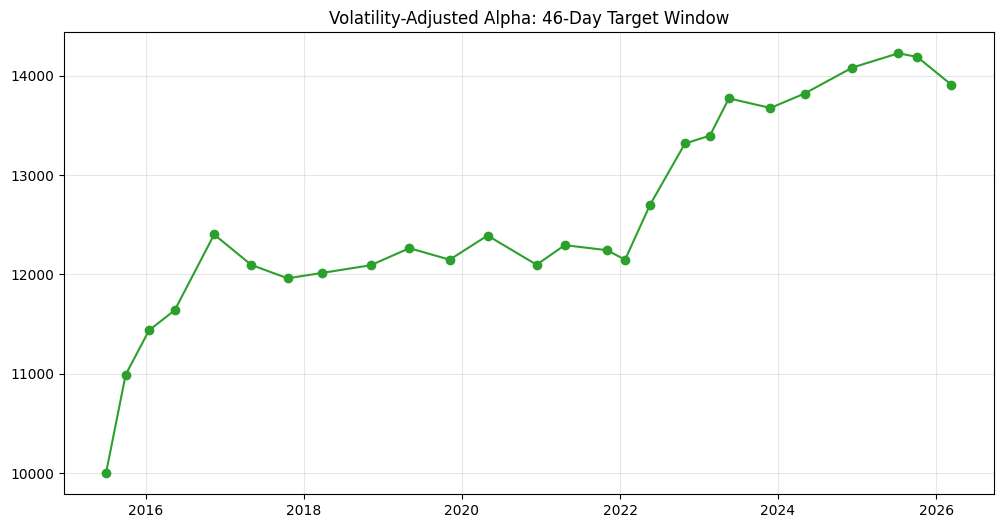

In [33]:
# Detect National Dips
radar_valleys, _ = find_peaks(-df['Radar_Z'], distance=60, height=1.00) 
radar_dip_dates = df.index[radar_valleys]

print(f"\nDetected {len(radar_dip_dates)} Systemic National Dips.")

# --- 2. ADAPTIVE LEAD TIME ANALYSIS ---
lead_times = []

for r_date in radar_dip_dates:
    # Get local volatility at the time of the dip to set dynamic prominence
    # Sensitivity factor of 0.5 - 1.0 is standard for 'Prominence'
    local_vol = df.loc[r_date, 'Rolling_Vol']
    dynamic_prominence = local_vol * 20.0
    
    # Search window for reaction: 90 days after dip
    search_end = r_date + pd.Timedelta(days=90)
    mask = (df.index > r_date) & (df.index <= search_end)
    search_period = df.loc[mask]
    
    if not search_period.empty:
        # Detect peaks in this specific window using dynamic prominence
        peaks, _ = find_peaks(search_period['Close'], prominence=dynamic_prominence)
        
        if len(peaks) > 0:
            first_peak_date = search_period.index[peaks[0]]
            lead_times.append((first_peak_date - r_date).days)
        else:
            lead_times.append(np.nan)
    else:
        lead_times.append(np.nan)

avg_lead = np.nanmean(lead_times)
med_lead = np.nanmedian(lead_times)

print(f"--- VOLATILITY-ADJUSTED LEAD ANALYSIS ---")
print(f"Average Lead: {avg_lead:.1f} days | Median Lead: {med_lead:.1f} days")

# --- 3. BACKTEST (Using Detected Median Lead) ---
optimal_hold = int(med_lead) if not np.isnan(med_lead) else 45

performance_stats = []
initial_capital = 10000
equity_curve = [initial_capital]
curve_dates = [df.index[0]]

for r_date in radar_dip_dates:
    price_at_dip = df.loc[r_date, 'Close']
    future_date = r_date + pd.Timedelta(days=optimal_hold)
    
    closest_idx = df.index.get_indexer([future_date], method='nearest')[0]
    actual_exit_date = df.index[closest_idx]
    
    trade_return = (df.iloc[closest_idx]['Close'] - price_at_dip) / price_at_dip
    performance_stats.append(trade_return)
    
    new_balance = equity_curve[-1] * (1 + trade_return)
    equity_curve.append(new_balance)
    curve_dates.append(actual_exit_date)

# 4. INSTITUTIONAL METRICS OUTPUT
if performance_stats:
    perf_array = np.array(performance_stats)
    eq_series = pd.Series(equity_curve)
    max_dd = ((eq_series - eq_series.cummax()) / eq_series.cummax()).min() * 100
    
    print(f"\n--- MACRO AGGREGATE RESULTS ({optimal_hold}D HOLD) ---")
    print(f"Win Rate: {(perf_array > 0).mean()*100:.1f}%")
    print(f"Sharpe Ratio: {np.mean(perf_array)/np.std(perf_array):.4f}")
    print(f"Sortino Ratio: {np.mean(perf_array)/np.std(perf_array[perf_array<0]):.4f}")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Final Value: ${equity_curve[-1]:,.2f}")

    # Plotting remains similar to your previous block
    plt.figure(figsize=(12, 6))
    plt.plot(curve_dates, equity_curve, marker='o', color='#2ca02c', label="Adaptive National Aggregate")
    plt.title(f"Volatility-Adjusted Alpha: {optimal_hold}-Day Target Window")
    plt.grid(True, alpha=0.3)
    plt.show()





--- SORTINO SENSITIVITY TEST (30-60 Days) ---


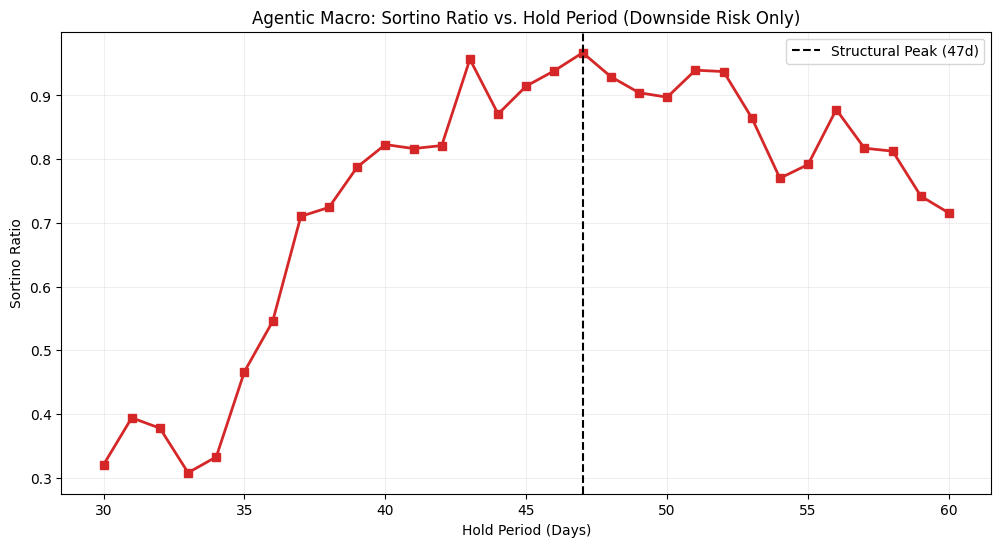

In [34]:
def run_sortino_sensitivity(df, radar_dip_dates, target_hurdle=0):
    print("\n--- SORTINO SENSITIVITY TEST (30-60 Days) ---")
    results = []
    
    for hold_period in range(30, 61):
        trade_returns = []
        for r_date in radar_dip_dates:
            price_at_dip = df.loc[r_date, 'Close']
            future_date = r_date + pd.Timedelta(days=hold_period)
            
            if future_date > df.index[-1]: continue
            
            idx = df.index.get_indexer([future_date], method='nearest')[0]
            ret = (df.iloc[idx]['Close'] - price_at_dip) / price_at_dip
            trade_returns.append(ret)
        
        if trade_returns:
            trade_returns = np.array(trade_returns)
            avg_ret = np.mean(trade_returns)
            
            # --- SORTINO CALCULATION ---
            # Calculate only 'Downside' deviation (returns below the hurdle)
            downside_diff = trade_returns[trade_returns < target_hurdle] - target_hurdle
            downside_deviation = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else 0.0001
            
            sortino = avg_ret / downside_deviation
            results.append({'Hold_Period': hold_period, 'Avg_Return': avg_ret * 100, 'Sortino': sortino})

    sensitivity_df = pd.DataFrame(results)
    
    # Plotting the "Sortino Hill"
    plt.figure(figsize=(12, 6))
    plt.plot(sensitivity_df['Hold_Period'], sensitivity_df['Sortino'], marker='s', color='#d62728', linewidth=2)
    plt.axvline(47, color='black', linestyle='--', label='Structural Peak (47d)')
    
    plt.title("Agentic Macro: Sortino Ratio vs. Hold Period (Downside Risk Only)")
    plt.xlabel("Hold Period (Days)")
    plt.ylabel("Sortino Ratio")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

run_sortino_sensitivity(df, radar_dip_dates)


In [35]:
def run_shuffle_test(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"\n--- SHUFFLE TEST ({iterations} Iterations) ---")
    
    # 1. Calculate the Actual Strategy Performance
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        future_date = r_date + pd.Timedelta(days=hold_period)
        if future_date > df.index[-1]: continue
        idx = df.index.get_indexer([future_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_mean = np.mean(actual_returns)

    # 2. Run the Shuffles (Monte Carlo)
    # We keep the DATES of the trades but shuffle the PRICE RETURNS
    simulated_means = []
    returns_pool = df['Log_Ret'].dropna().values
    
    for _ in range(iterations):
        # Create a "fake" price series from shuffled returns
        shuffled_returns = np.random.choice(returns_pool, size=len(actual_returns))
        simulated_means.append(np.mean(shuffled_returns))

    # 3. Calculate P-Value (How often did a random shuffle beat our strategy?)
    p_val_shuffle = (np.array(simulated_means) >= actual_mean).mean()
    
    print(f"Actual Mean Return: {actual_mean*100:.4f}%")
    print(f"Shuffle P-Value: {p_val_shuffle:.4f}")
    print(f"Significance: {'HIGH' if p_val_shuffle < 0.05 else 'None'}")

run_shuffle_test(df, radar_dip_dates)



--- SHUFFLE TEST (5000 Iterations) ---
Actual Mean Return: 1.4117%
Shuffle P-Value: 0.0000
Significance: HIGH


Running 5000 shuffles to generate distribution...


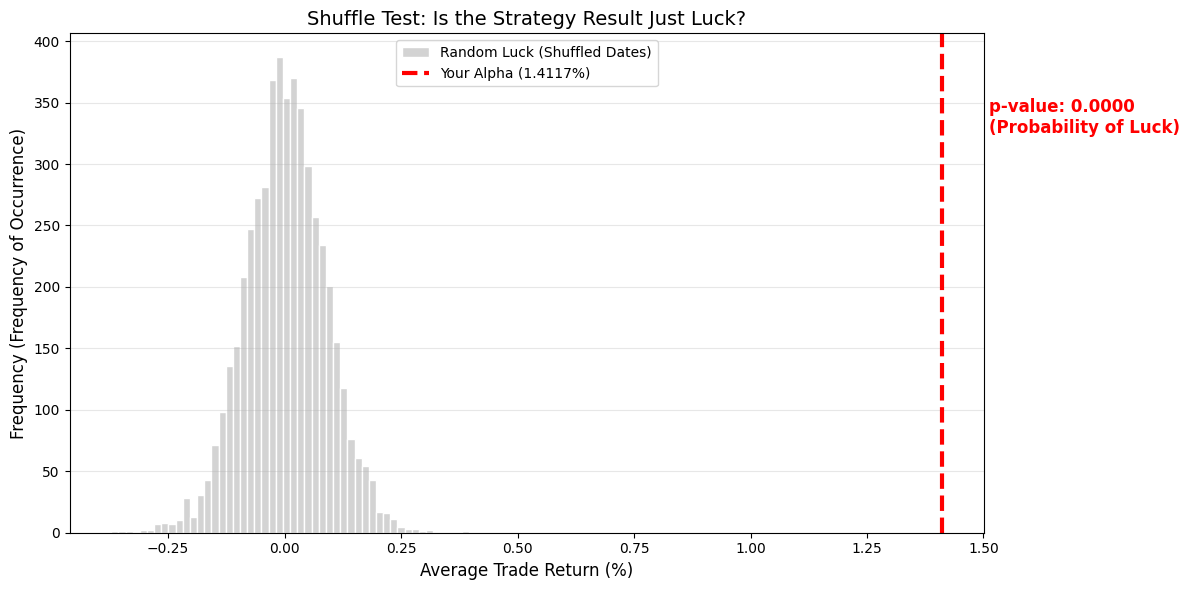

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def plot_shuffle_test(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"Running {iterations} shuffles to generate distribution...")
    
    # 1. Calculate Actual Strategy Mean
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        future_date = r_date + pd.Timedelta(days=hold_period)
        if future_date > df.index[-1]: continue
        idx = df.index.get_indexer([future_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_mean = np.mean(actual_returns) * 100 # Convert to %

    # 2. Run the Monte Carlo Shuffles
    # We sample from the pool of daily log returns to create 'random' trades
    returns_pool = df['Log_Ret'].dropna().values
    simulated_means = []
    
    for _ in range(iterations):
        # Pick 25 random days and calculate their mean return
        shuffled_sample = np.random.choice(returns_pool, size=len(actual_returns))
        simulated_means.append(np.mean(shuffled_sample) * 100)

    # 3. Plotting the Distribution
    plt.figure(figsize=(12, 6))
    
    # Plot the 'Null Hypothesis' (The Luck Zone)
    plt.hist(simulated_means, bins=50, color='lightgray', edgecolor='white', label='Random Luck (Shuffled Dates)')
    
    # Plot Your Strategy Result
    plt.axvline(actual_mean, color='red', linestyle='--', linewidth=3, label=f'Your Alpha ({actual_mean:.4f}%)')
    
    # Formatting
    plt.title("Shuffle Test: Is the Strategy Result Just Luck?", fontsize=14)
    plt.xlabel("Average Trade Return (%)", fontsize=12)
    plt.ylabel("Frequency (Frequency of Occurrence)", fontsize=12)
    
    # Annotate the 'P-Value'
    p_val = (np.array(simulated_means) >= actual_mean).mean()
    plt.text(actual_mean + 0.1, plt.ylim()[1]*0.8, f"p-value: {p_val:.4f}\n(Probability of Luck)", 
             color='red', fontweight='bold', fontsize=12)
    
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the plot
plot_shuffle_test(df, radar_dip_dates)



--- VOLATILITY SHUFFLE: SORTINO EDITION (5000 Iterations) ---
Actual Sortino: 0.9670
Sortino-Shuffle P-Value: 0.0564
RESULT: Marginal (0.0564). Trade volume (N=24) limits confidence.


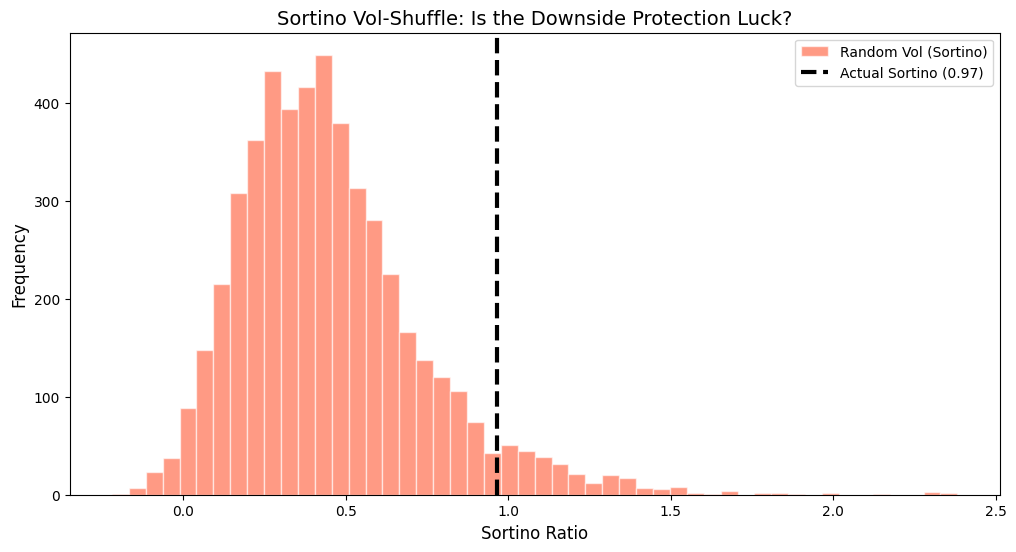

In [37]:
def run_sortino_vol_shuffle(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"\n--- VOLATILITY SHUFFLE: SORTINO EDITION ({iterations} Iterations) ---")
    
    # 1. Calculate Actual Strategy Sortino
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        exit_date = r_date + pd.Timedelta(days=hold_period)
        if exit_date > df.index[-1]: continue
        idx = df.index.get_indexer([exit_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_returns = np.array(actual_returns)
    actual_mean = np.mean(actual_returns)
    # Conservative Sortino calculation (Root Mean Square of Downside)
    downside = actual_returns[actual_returns < 0]
    actual_sortino = actual_mean / np.sqrt(np.mean(downside**2)) if len(downside) > 0 else 5.0

    # 2. Run the Vol-Shuffles
    daily_rets = df['Log_Ret'].dropna().values
    signs = np.sign(daily_rets)
    magnitudes = np.abs(daily_rets)
    
    simulated_sortinos = []
    
    for _ in range(iterations):
        shuffled_mags = np.random.permutation(magnitudes)
        fake_rets = signs * shuffled_mags
        fake_price_curve = np.exp(np.cumsum(np.insert(fake_rets, 0, 0)))
        
        fake_trade_returns = []
        for r_date in radar_dip_dates:
            orig_idx = df.index.get_loc(r_date)
            entry_val = fake_price_curve[orig_idx]
            exit_date = r_date + pd.Timedelta(days=hold_period)
            if exit_date > df.index[-1]: continue
            exit_idx = df.index.get_indexer([exit_date], method='nearest')[0]
            exit_val = fake_price_curve[exit_idx]
            fake_trade_returns.append((exit_val - entry_val) / entry_val)

        if fake_trade_returns:
            f_rets = np.array(fake_trade_returns)
            f_downside = f_rets[f_rets < 0]
            f_sortino = np.mean(f_rets) / np.sqrt(np.mean(f_downside**2)) if len(f_downside) > 0 else 0
            simulated_sortinos.append(f_sortino)

    # 3. P-Value and Plotting
    sim_array = np.array(simulated_sortinos)
    p_val_sortino = (sim_array >= actual_sortino).mean()
    
    plt.figure(figsize=(12, 6))
    plt.hist(sim_array, bins=50, color='#FF5733', edgecolor='white', alpha=0.6, label='Random Vol (Sortino)')
    plt.axvline(actual_sortino, color='black', linestyle='--', linewidth=3, label=f'Actual Sortino ({actual_sortino:.2f})')
    
    plt.title("Sortino Vol-Shuffle: Is the Downside Protection Luck?", fontsize=14)
    plt.xlabel("Sortino Ratio", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()
    
    print(f"Actual Sortino: {actual_sortino:.4f}")
    print(f"Sortino-Shuffle P-Value: {p_val_sortino:.4f}")
    
    if p_val_sortino < 0.05:
        print("RESULT: High Significance! Your downside protection is non-random.")
    else:
        print(f"RESULT: Marginal ({p_val_sortino:.4f}). Trade volume (N={len(actual_returns)}) limits confidence.")
    plt.show()

run_sortino_vol_shuffle(df, radar_dip_dates)
